In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (replace the file path with your actual file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)
df

,Timestamp,ServingCellID,PCellRSRP,PCellRSRQ,NeighCellId,NeighCellRSRP,NeighCellRSRQ,Handover,CINRvalue1,CINRvalue2,CINR
0,46:26.3,50,51,6.0,77,49.0,6.0,0,11,9,10.0
1,46:26.3,50,51,6.0,162,47.0,4.0,0,11,9,10.0
2,46:28.4,50,52,10.0,77,46.0,2.0,0,11,9,10.0
3,46:38.9,50,48,4.0,77,47.0,7.0,0,1,-1,0.0
4,46:39.3,50,51,6.0,77,49.0,6.0,0,2,-4,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
642,32:15.1,306,68,24.0,328,56.0,21.0,1,0,2,1.0
643,32:15.3,328,57,12.0,308,56.0,7.0,0,0,2,1.0
644,32:15.9,328,55,13.0,308,56.0,7.0,0,0,2,1.0
645,32:21.9,328,59,15.0,308,56.0,7.0,0,15,13,14.0


In [ ]:
# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      647 non-null    object 
 1   ServingCellID  647 non-null    int64  
 2   PCellRSRP      647 non-null    int64  
 3   PCellRSRQ      647 non-null    float64
 4   NeighCellId    647 non-null    int64  
 5   NeighCellRSRP  647 non-null    float64
 6   NeighCellRSRQ  647 non-null    float64
 7   Handover       647 non-null    int64  
 8   CINRvalue1     647 non-null    int64  
 9   CINRvalue2     647 non-null    int64  
 10  CINR           647 non-null    float64
dtypes: float64(4), int64(6), object(1)
memory usage: 55.7+ KB
None

Basic Statistics:
       ServingCellID   PCellRSRP   PCellRSRQ  NeighCellId  NeighCellRSRP  \
count     647.000000  647.000000  647.000000    647.00000     647.000000   
mean      240.740340   51.826893   10.820711    207.16847      50.3724

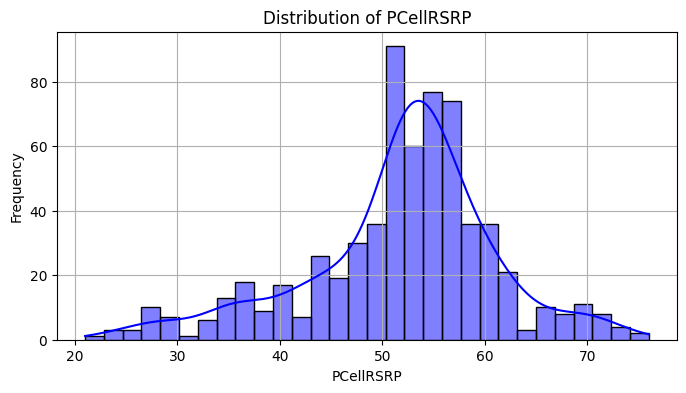

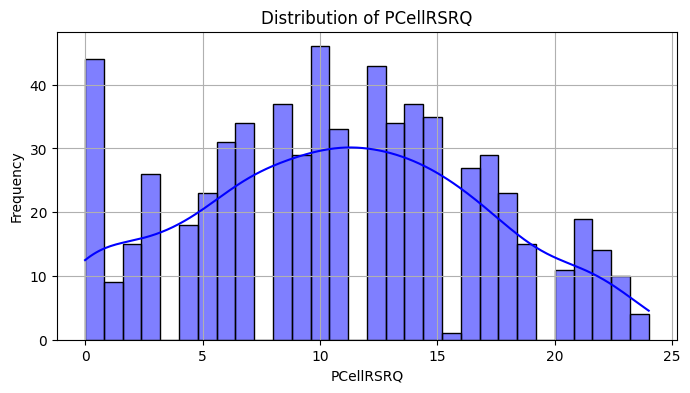

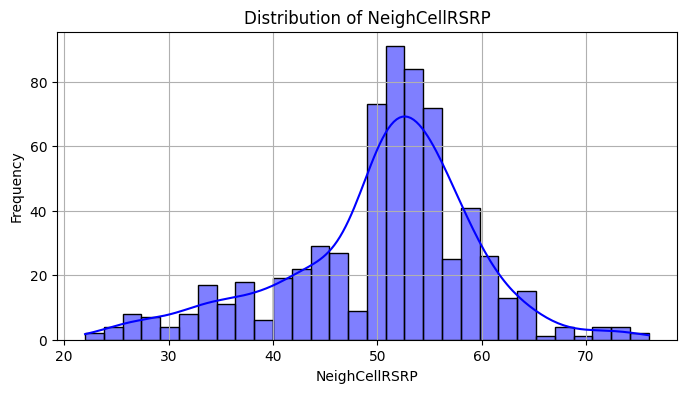

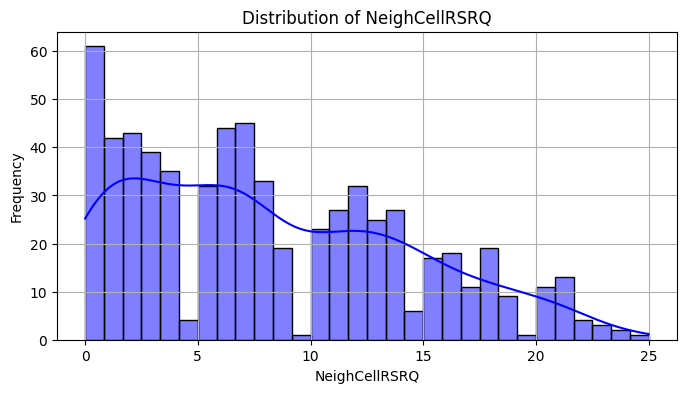

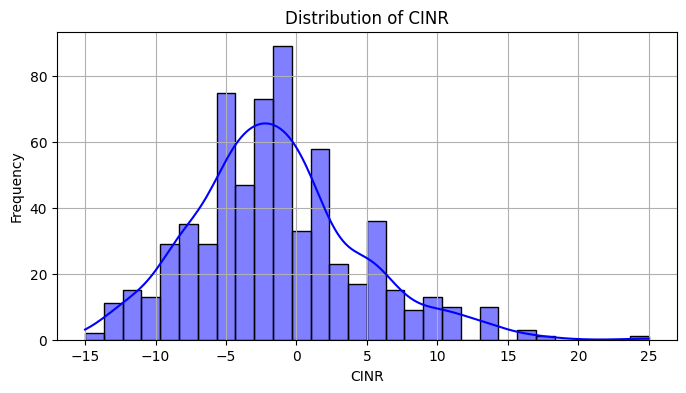

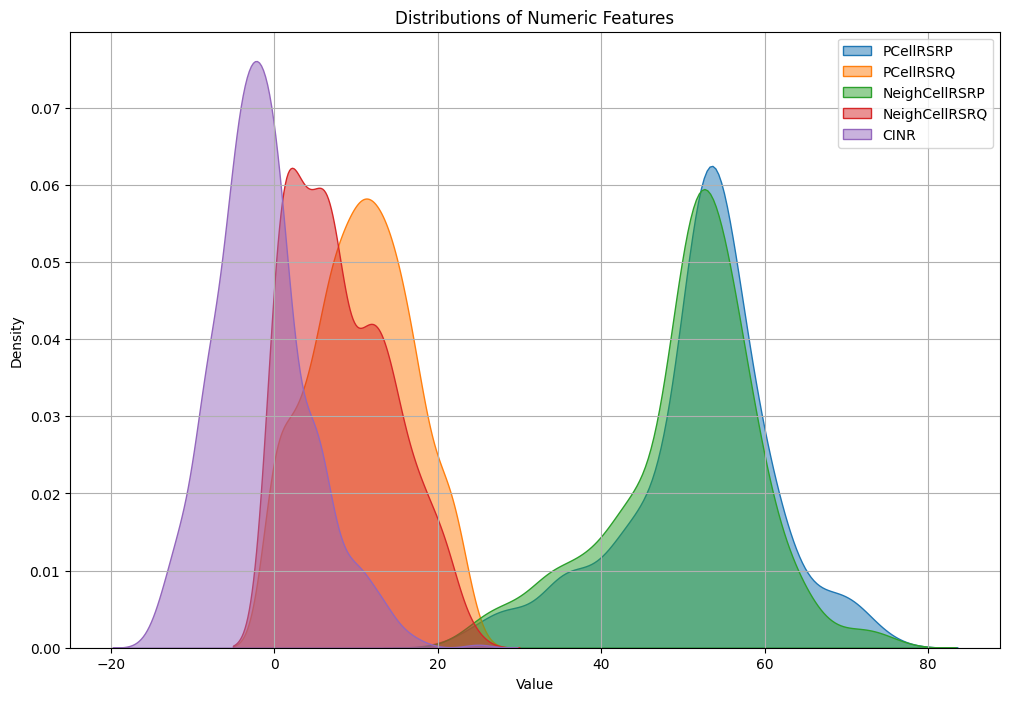

In [ ]:
# Plot distribution of numeric features
numeric_features = ['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ',
                     'CINR']

for feature in numeric_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[feature].dropna(), kde=True, bins=30, color="blue")
        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()


# Plot all numeric feature distributions in one plot
plt.figure(figsize=(12, 8))

for feature in numeric_features:
    if feature in df.columns:
        sns.kdeplot(df[feature].dropna(), label=feature, fill=True, alpha=0.5)

plt.title("Distributions of Numeric Features")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)

# Count unique values for ServingCellID (PCell)
print("Unique ServingCellID (PCell):")
serving_cell_counts = df['ServingCellID'].value_counts()
print(serving_cell_counts)
print(f"Total unique ServingCellID (PCell): {df['ServingCellID'].nunique()}")

# Count unique values for NeighCellId (Neighbor Cell)
print("\nUnique NeighCellId (Neighbor Cell):")
neighbor_cell_counts = df['NeighCellId'].value_counts()
print(neighbor_cell_counts)
print(f"Total unique NeighCellId (Neighbor Cell): {df['NeighCellId'].nunique()}")

# Count the number of handovers (assuming 'Handover' column is binary: 1 for handover, 0 for non-handover)
handover_counts = df['Handover'].value_counts()

print("Handover Counts:")
print(f"Number of Handovers: {handover_counts.get(1, 0)}")
print(f"Number of Non-Handovers: {handover_counts.get(0, 0)}")

Unique ServingCellID (PCell):
ServingCellID
297    111
301     96
152     33
58      32
325     28
305     27
299     25
234     24
365     23
47      22
244     22
196     22
150     16
291     16
33      14
306     13
151     11
235     11
327     11
50       9
195      9
348      8
328      8
34       6
326      6
264      5
57       4
353      4
77       3
292      3
100      3
36       3
197      3
403      3
60       3
349      2
30       2
63       2
371      2
37       1
259      1
Name: count, dtype: int64
Total unique ServingCellID (PCell): 41

Unique NeighCellId (Neighbor Cell):
NeighCellId
299    72
297    68
152    59
301    43
150    38
       ..
124     1
123     1
36      1
60      1
306     1
Name: count, Length: 66, dtype: int64
Total unique NeighCellId (Neighbor Cell): 66
Handover Counts:
Number of Handovers: 94
Number of Non-Handovers: 553


Correlation Matrix (Without CINRvalue1 and CINRvalue2):
               PCellRSRP  PCellRSRQ  NeighCellRSRP  NeighCellRSRQ  Handover  \
PCellRSRP       1.000000   0.324265       0.781224       0.142154 -0.129956   
PCellRSRQ       0.324265   1.000000       0.106224       0.451617 -0.216411   
NeighCellRSRP   0.781224   0.106224       1.000000       0.289729  0.137923   
NeighCellRSRQ   0.142154   0.451617       0.289729       1.000000  0.265236   
Handover       -0.129956  -0.216411       0.137923       0.265236  1.000000   
CINR            0.136634   0.421401       0.053280       0.280499  0.005687   

                   CINR  
PCellRSRP      0.136634  
PCellRSRQ      0.421401  
NeighCellRSRP  0.053280  
NeighCellRSRQ  0.280499  
Handover       0.005687  
CINR           1.000000  


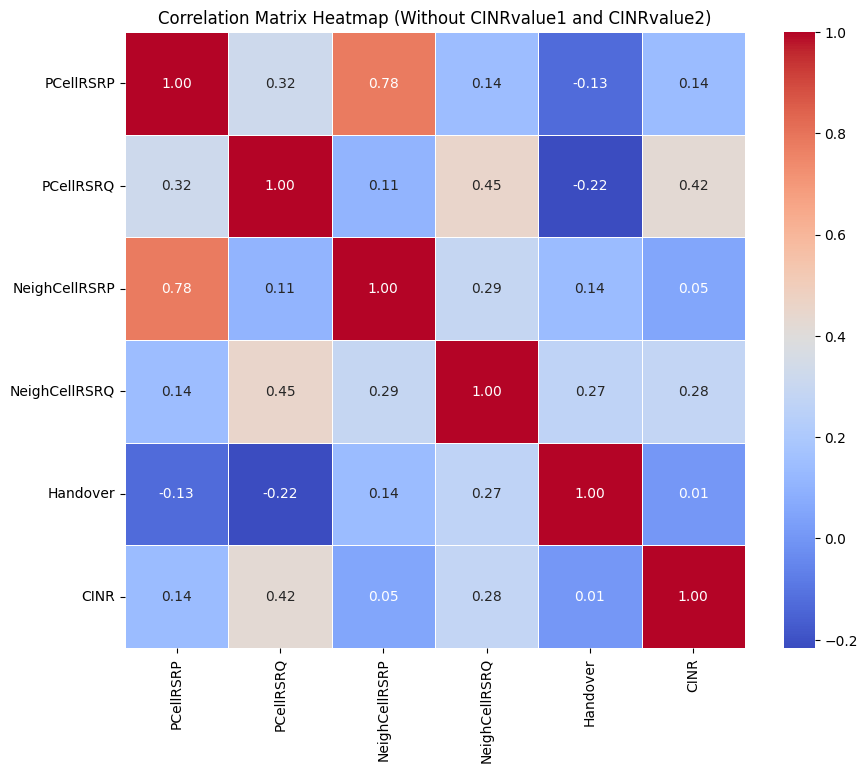

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (replace the file path with your actual file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Exclude CINRvalue1 and CINRvalue2
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', "Timestamp", "ServingCellID" , "NeighCellId" ], errors='ignore')

# Compute the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix (Without CINRvalue1 and CINRvalue2):")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Without CINRvalue1 and CINRvalue2)")
plt.show()

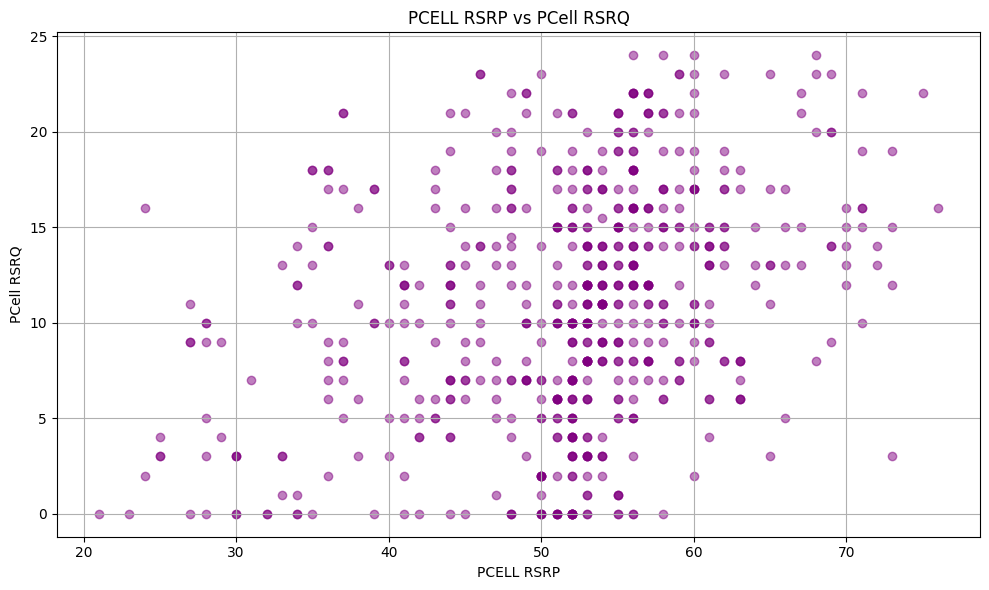

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Drop unnecessary columns (CINRvalue1, CINRvalue2, ServingCellID, NeighCellId)
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', 'ServingCellID', 'NeighCellId'], errors='ignore')

# Plotting RCELL RSRP vs PCell RSRQ
plt.figure(figsize=(10, 6))

plt.scatter(df['PCellRSRP'], df['PCellRSRQ'], alpha=0.5, color='purple')
plt.xlabel('PCELL RSRP')
plt.ylabel('PCell RSRQ')
plt.title('PCELL RSRP vs PCell RSRQ')
plt.grid(True)
plt.tight_layout()
plt.show()

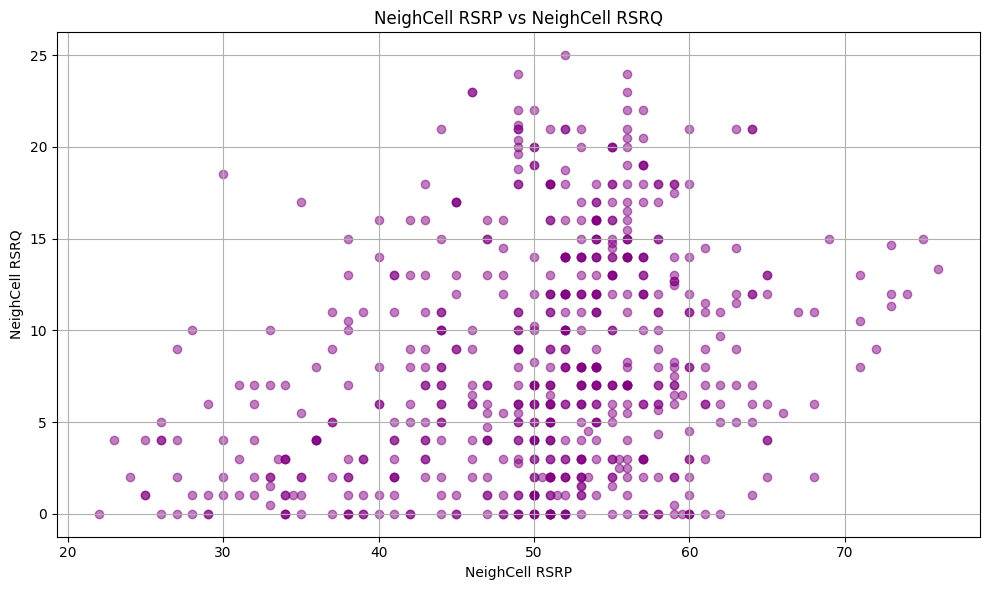

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Drop unnecessary columns (CINRvalue1, CINRvalue2, ServingCellID, NeighCellId)
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', 'ServingCellID', 'NeighCellId'], errors='ignore')

# Plotting RCELL RSRP vs PCell RSRQ
plt.figure(figsize=(10, 6))

plt.scatter(df['NeighCellRSRP'], df['NeighCellRSRQ'], alpha=0.5, color='purple')
plt.xlabel('NeighCell RSRP')
plt.ylabel('NeighCell RSRQ')
plt.title('NeighCell RSRP vs NeighCell RSRQ')
plt.grid(True)
plt.tight_layout()
plt.show()

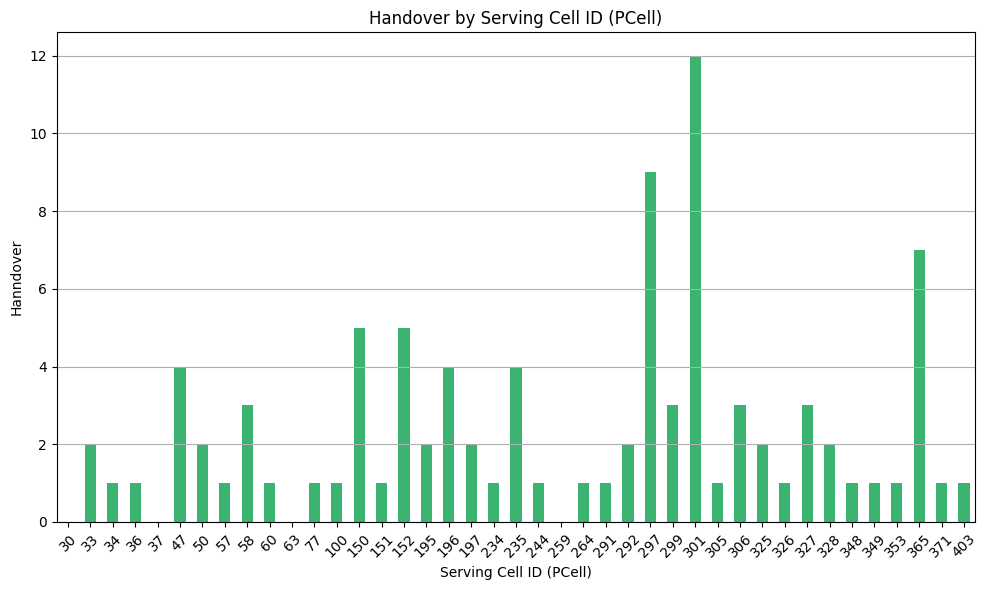

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns for this task (if any)
df_cleaned = df.drop(columns=['CINRvalue1', 'CINRvalue2', 'Timestamp', 'NeighCellId'], errors='ignore')

# Assuming 'Handover' column contains 1 for successful handover and 0 for failure
# Calculate handover success rate by ServingCellID (PCell)
success_rate_by_cell = df_cleaned.groupby('ServingCellID')['Handover'].sum()

# Plotting Handover Success Rate by ServingCellID (PCell)
plt.figure(figsize=(10, 6))
success_rate_by_cell.plot(kind='bar', color='mediumseagreen')
plt.title('Handover by Serving Cell ID (PCell)')
plt.xlabel('Serving Cell ID (PCell)')
plt.ylabel('Hanndover')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

Accuracy: 0.8974
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       167
           1       0.90      0.32      0.47        28

    accuracy                           0.90       195
   macro avg       0.90      0.66      0.71       195
weighted avg       0.90      0.90      0.88       195

Threshold: 0.5
Accuracy: 0.8974
Precision: 0.9000
Recall: 0.3214
F1 Score: 0.4737
AUC: 0.9256


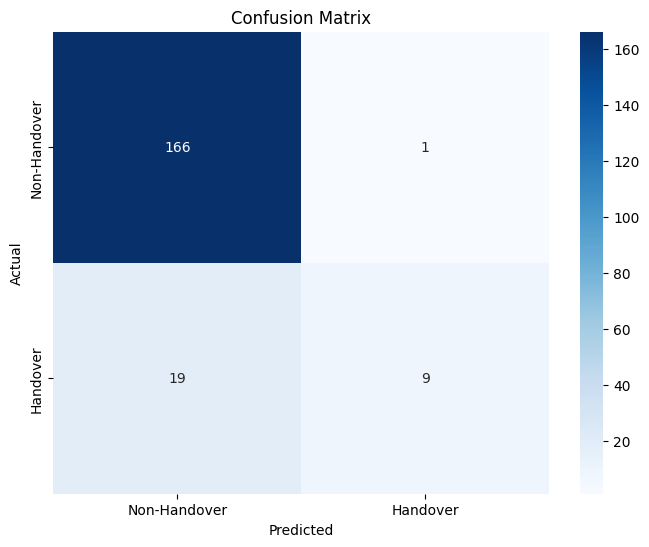

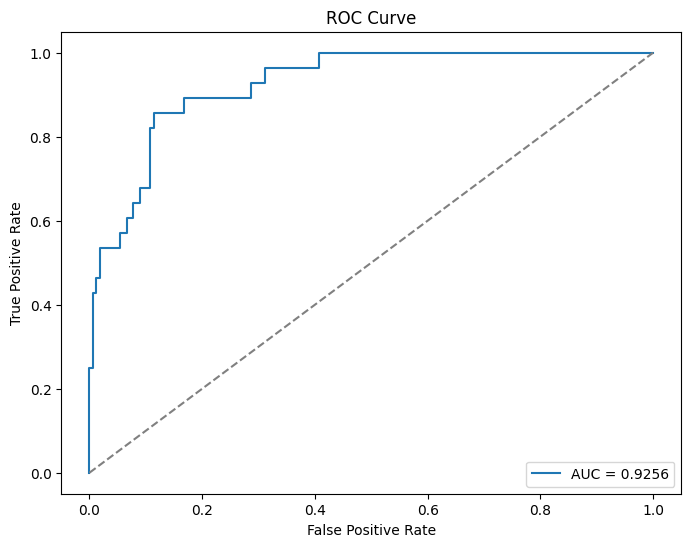

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8769
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93       167
           1       0.55      0.79      0.65        28

    accuracy                           0.88       195
   macro avg       0.76      0.84      0.79       195
weighted avg       0.90      0.88      0.89       195

Threshold: 0.5
Accuracy: 0.8769
Precision: 0.5500
Recall: 0.7857
F1 Score: 0.6471
AUC: 0.9256


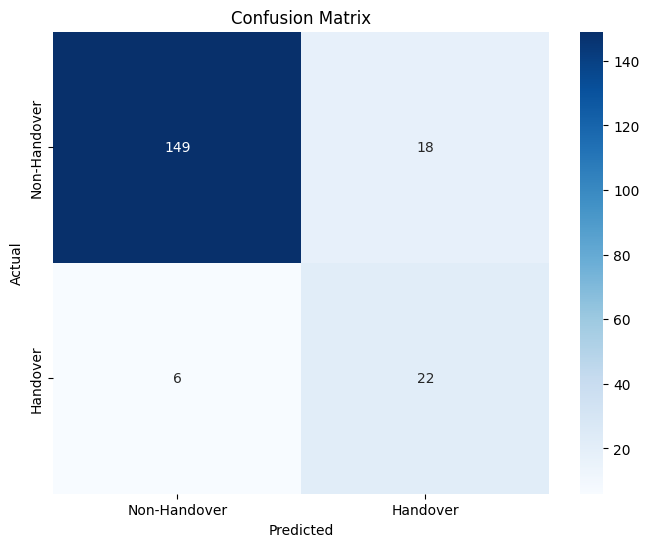

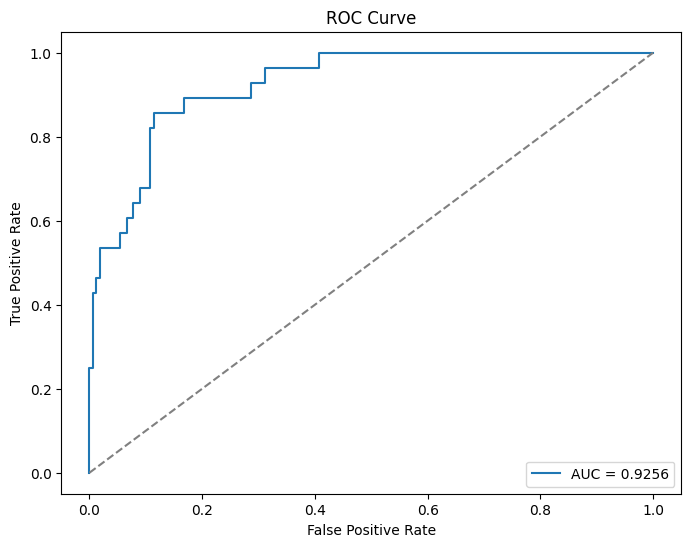

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Best F1-score: 0.6761
Best Parameters: {'C': 3.001, 'penalty': 'l2'}
Accuracy: 0.8821
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       167
           1       0.56      0.86      0.68        28

    accuracy                           0.88       195
   macro avg       0.77      0.87      0.80       195
weighted avg       0.91      0.88      0.89       195



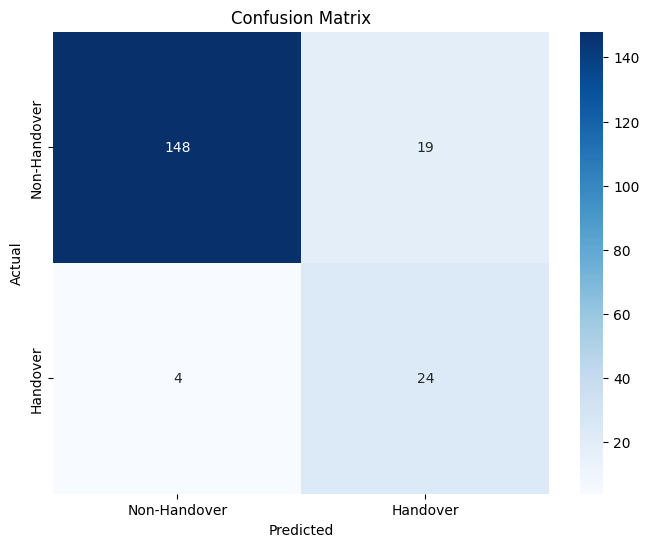

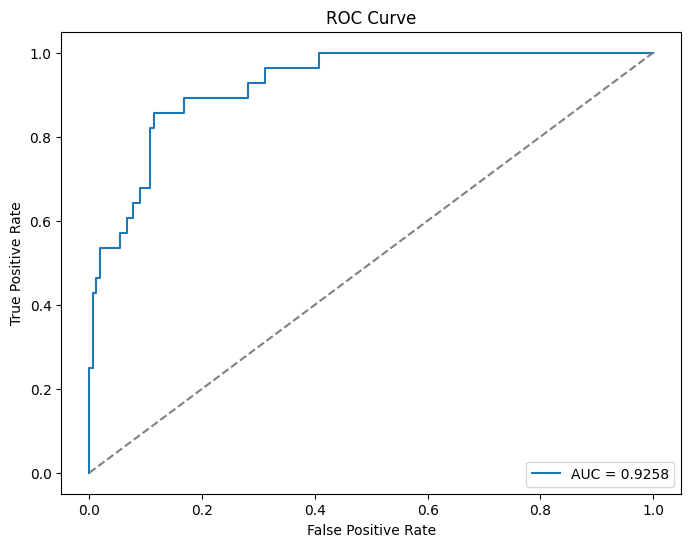

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for-loops
best_f1 = 0
best_params = {}
C_values = np.arange(0.001, 10.1, 0.5)  # Regularization strength (step size 0.5)
penalties = ['l1', 'l2']  # Regularization type

for C in C_values:
    for penalty in penalties:
        try:
            model = LogisticRegression(C=C, penalty=penalty, solver='liblinear')
            model.fit(X_train_scaled, y_train_final)

            # Predict probabilities
            y_prob = model.predict_proba(X_test_scaled)[:, 1]

            # Convert probabilities to binary classification based on threshold
            threshold = 0.5
            y_pred = (y_prob >= threshold).astype(int)

            # Evaluate using F1-score
            f1 = f1_score(y_test, y_pred)

            if f1 > best_f1:
                best_f1 = f1
                best_params = {'C': C, 'penalty': penalty}

        except Exception as e:
            print(f"Skipping C={C}, penalty={penalty} due to error: {e}")

# Train the best model
best_model = LogisticRegression(C=best_params['C'], penalty=best_params['penalty'], solver='liblinear')
best_model.fit(X_train_scaled, y_train_final)

# Predict using best model
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Final evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

print(f"Best F1-score: {best_f1:.4f}")
print(f"Best Parameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       167
           1       0.45      0.36      0.40        28

    accuracy                           0.85       195
   macro avg       0.68      0.64      0.66       195
weighted avg       0.83      0.85      0.84       195

Threshold: 0.5
Accuracy: 0.8462
Precision: 0.4545
Recall: 0.3571
F1 Score: 0.4000
AUC: 0.6426


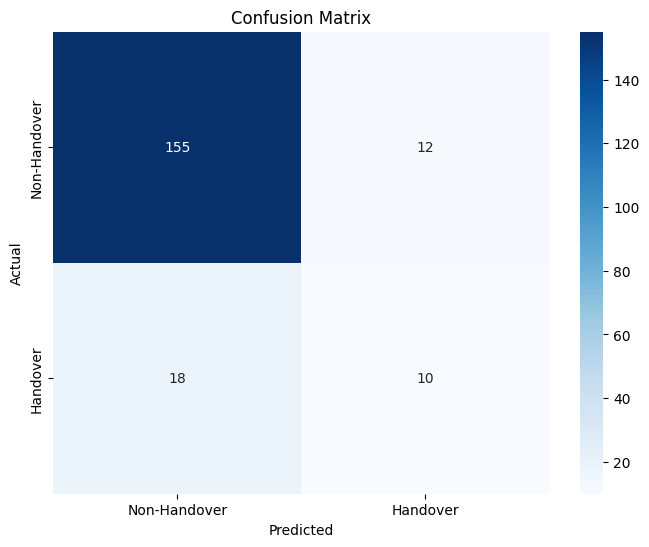

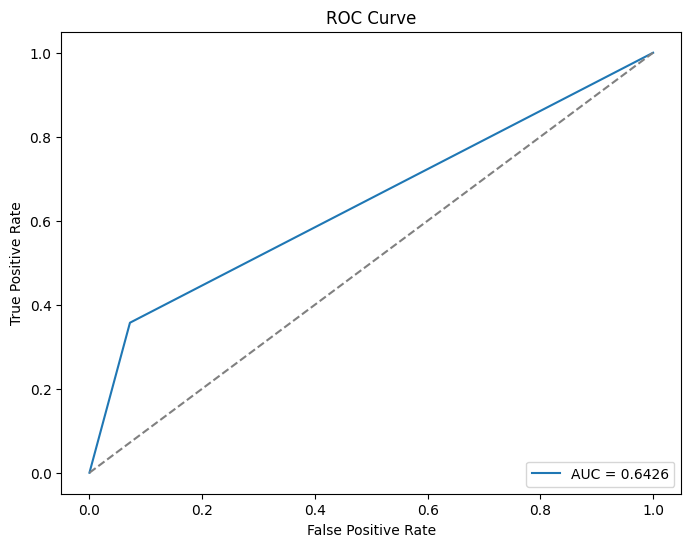

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Decision Tree model with class weighting to handle class imbalance
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the model
dt_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Accuracy: 0.8051
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       167
           1       0.34      0.39      0.37        28

    accuracy                           0.81       195
   macro avg       0.62      0.63      0.63       195
weighted avg       0.82      0.81      0.81       195

Threshold: 0.5
Accuracy: 0.8051
Precision: 0.3438
Recall: 0.3929
F1 Score: 0.3667
AUC: 0.6336


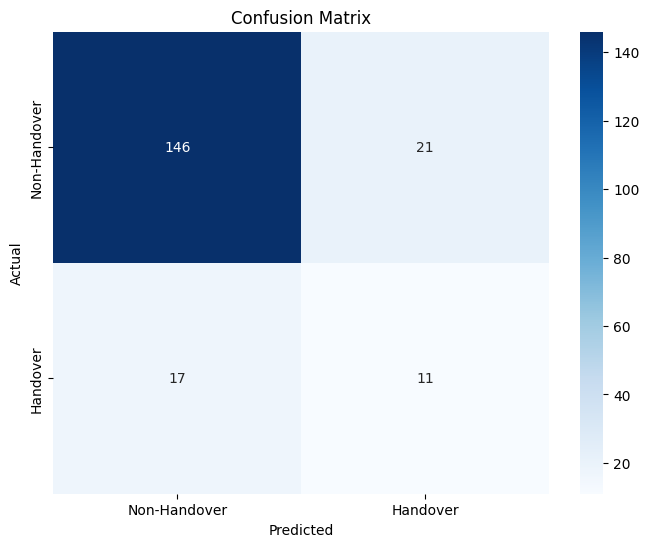

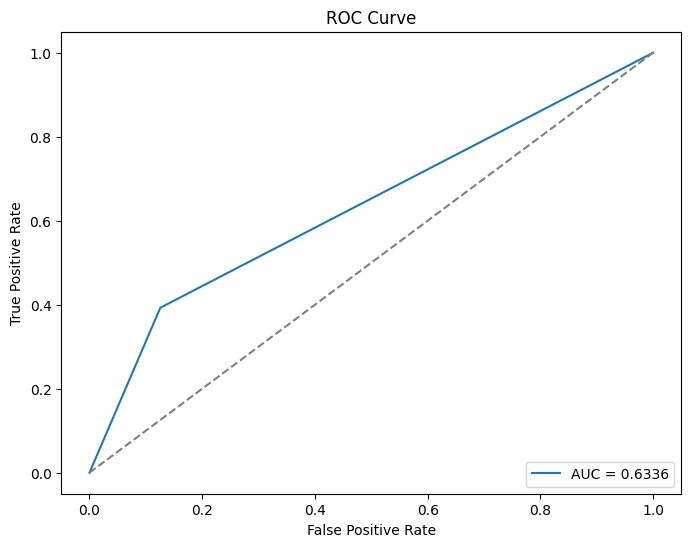

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Additional Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Best Hyperparameters: {'max_depth': 4, 'min_samples_split': 2}
Best F1 Score: 0.5000
Best Model - Accuracy: 0.8667
Best Model - Precision: 0.5417
Best Model - Recall: 0.4643
Best Model - F1 Score: 0.5000
Best Model - AUC: 0.7746

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       167
           1       0.54      0.46      0.50        28

    accuracy                           0.87       195
   macro avg       0.73      0.70      0.71       195
weighted avg       0.86      0.87      0.86       195



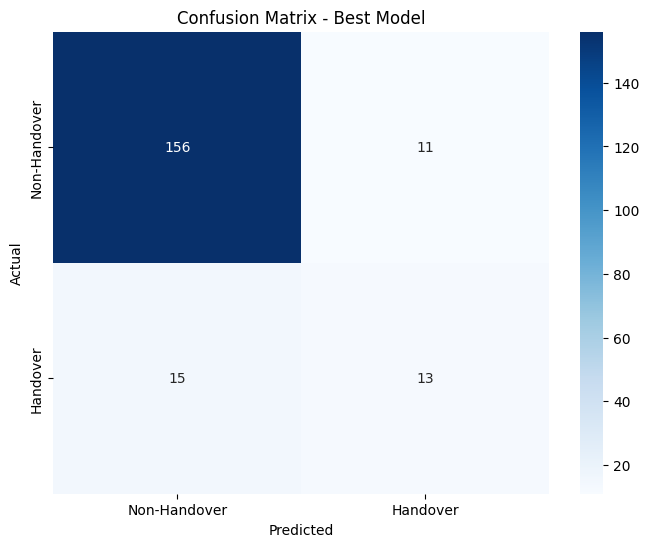

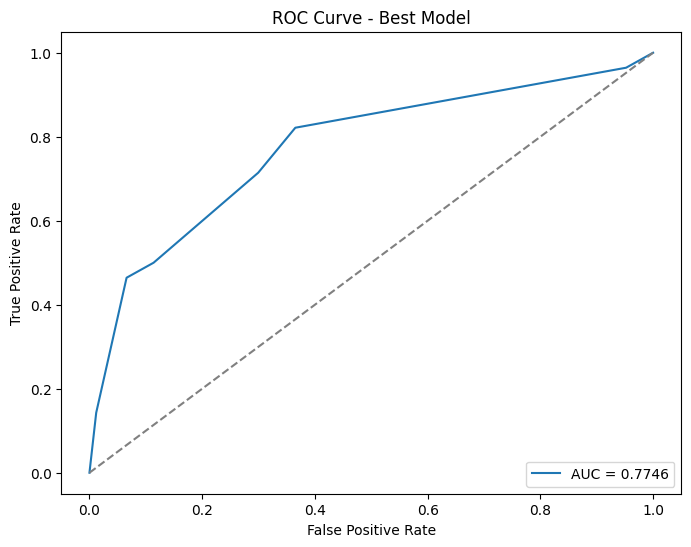

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for loops with arange
best_f1 = 0
best_params = {}

# Define the range for max_depth and min_samples_split
max_depth_range = np.arange(1, 11, 1)  # max_depth values from 1 to 10
min_samples_split_range = np.arange(2, 11, 1)  # min_samples_split values from 2 to 10

# Loop through hyperparameters
for max_depth in max_depth_range:
    for min_samples_split in min_samples_split_range:

        # Train Decision Tree model with current hyperparameters
        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
        model.fit(X_train_scaled, y_train)

        # Predict probabilities for class 1 (Handover = 1)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

        # Convert probabilities to binary classification based on threshold
        threshold = 0.5
        y_pred = (y_proba >= threshold).astype(int)

        # Calculate F1 score
        f1 = f1_score(y_test, y_pred)

        # If the F1 score is the best so far, save the parameters
        if f1 > best_f1:
            best_f1 = f1
            best_params = {'max_depth': max_depth, 'min_samples_split': min_samples_split}

# Output the best hyperparameters and the corresponding F1 score
print(f"Best Hyperparameters: {best_params}")
print(f"Best F1 Score: {best_f1:.4f}")

# Train Decision Tree model with the best hyperparameters
best_model = DecisionTreeClassifier(max_depth=best_params['max_depth'], min_samples_split=best_params['min_samples_split'], random_state=42)
best_model.fit(X_train_scaled, y_train)

# Predict probabilities for class 1 (Handover = 1) using the best model
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_best = (y_proba_best >= threshold).astype(int)

# Evaluate best model
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_proba_best)
fpr_best, tpr_best, thresholds_roc_best = roc_curve(y_test, y_proba_best)

# Displaying results
print(f"Best Model - Accuracy: {accuracy_best:.4f}")
print(f"Best Model - Precision: {precision_best:.4f}")
print(f"Best Model - Recall: {recall_best:.4f}")
print(f"Best Model - F1 Score: {f1_best:.4f}")
print(f"Best Model - AUC: {auc_best:.4f}")

# Classification Report for Best Model
print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot for Best Model
plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, label=f"AUC = {auc_best:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - Best Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8821
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       167
           1       0.65      0.39      0.49        28

    accuracy                           0.88       195
   macro avg       0.78      0.68      0.71       195
weighted avg       0.87      0.88      0.87       195

Threshold: 0.5
Accuracy: 0.8821
Precision: 0.6471
Recall: 0.3929
F1 Score: 0.4889
AUC: 0.8998


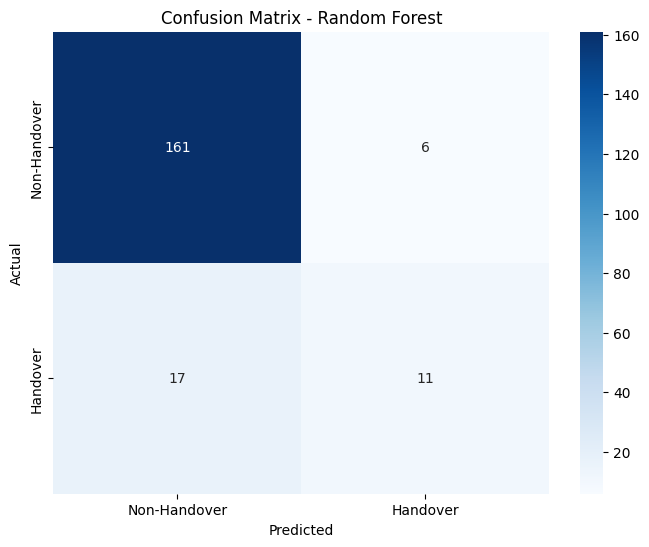

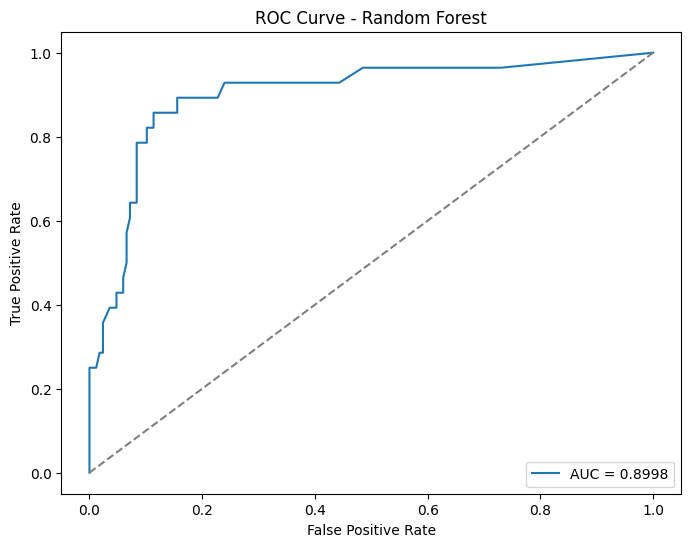

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# Evaluate model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print("Classification Report:\n", report_rf)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Precision
precision_rf = precision_score(y_test, y_pred_rf)

# Recall
recall_rf = recall_score(y_test, y_pred_rf)

# F1 Score
f1_rf = f1_score(y_test, y_pred_rf)

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# AUC (Area Under the Curve)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# ROC Curve
fpr_rf, tpr_rf, thresholds_roc_rf = roc_curve(y_test, y_proba_rf)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8205
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89       167
           1       0.43      0.75      0.55        28

    accuracy                           0.82       195
   macro avg       0.69      0.79      0.72       195
weighted avg       0.88      0.82      0.84       195

Threshold: 0.5
Accuracy: 0.8205
Precision: 0.4286
Recall: 0.7500
F1 Score: 0.5455
AUC: 0.8528


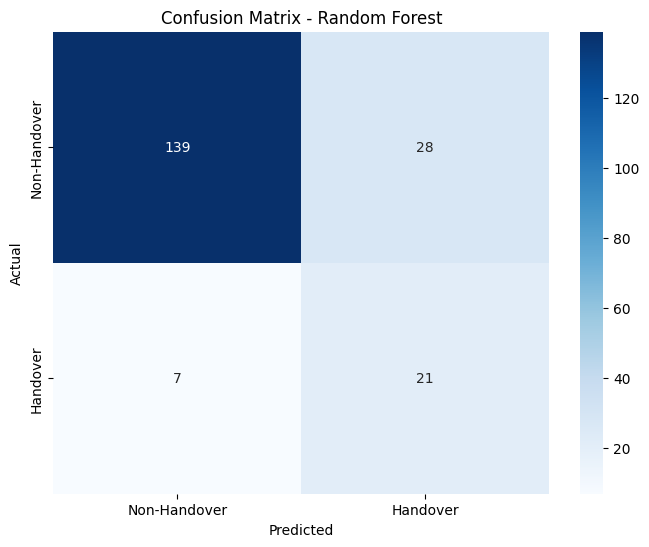

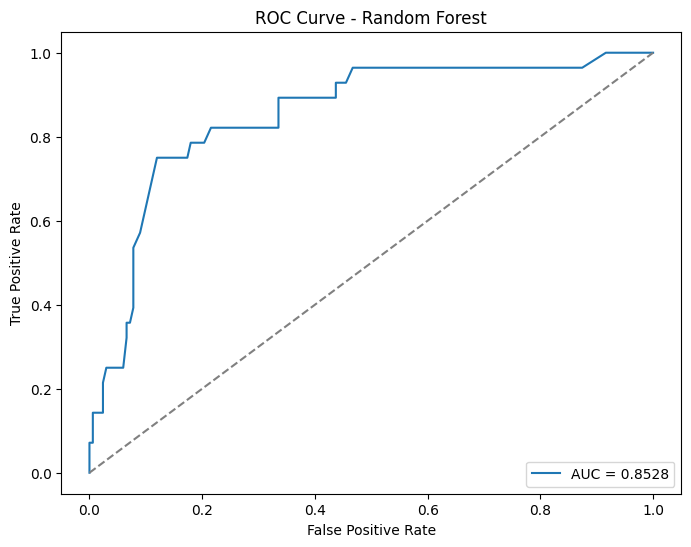

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_rf = (y_prob_rf >= threshold).astype(int)

# Evaluate model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print("Classification Report:\n", report_rf)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Precision
precision_rf = precision_score(y_test, y_pred_rf)

# Recall
recall_rf = recall_score(y_test, y_pred_rf)

# F1 Score
f1_rf = f1_score(y_test, y_pred_rf)

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# AUC (Area Under the Curve)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# ROC Curve
fpr_rf, tpr_rf, thresholds_roc_rf = roc_curve(y_test, y_prob_rf)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Best Hyperparameters: {'n_estimators': 30, 'max_depth': 9, 'min_samples_split': 3}
Best F1 Score: 0.6111
Precision: 0.5000
Recall: 0.7857
F1 Score: 0.6111
AUC: 0.8437

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       167
           1       0.50      0.79      0.61        28

    accuracy                           0.86       195
   macro avg       0.73      0.83      0.76       195
weighted avg       0.89      0.86      0.87       195



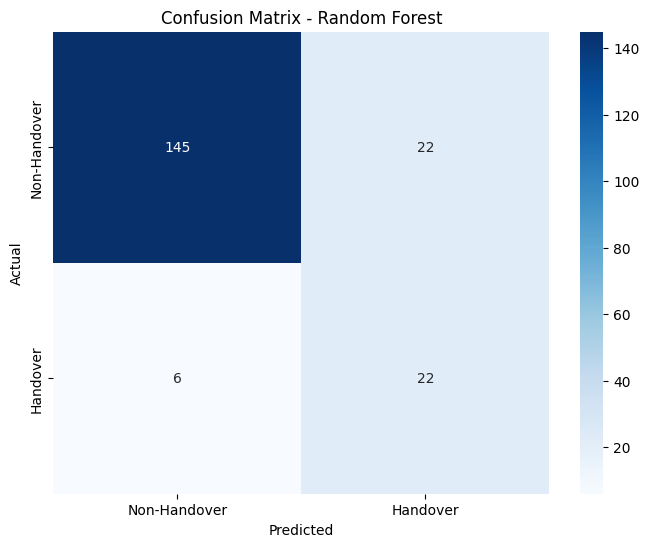

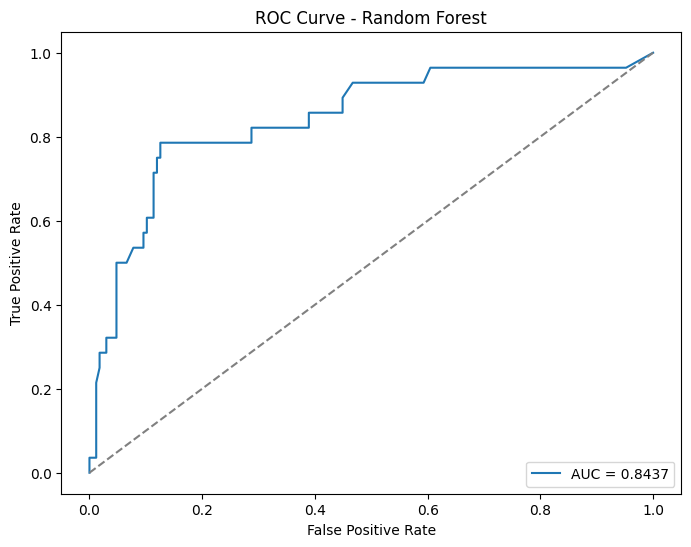

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for loop with arange
best_f1 = 0
best_params = {}

# Hyperparameter search space
n_estimators_range = np.arange(10, 201, 10)  # From 10 to 200 estimators
max_depth_range = np.arange(5, 21, 2)  # From 5 to 20 max depth
min_samples_split_range = np.arange(2, 11, 1)  # From 2 to 10 minimum samples per split

# Loop through all combinations of hyperparameters
for n_estimators in n_estimators_range:
    for max_depth in max_depth_range:
        for min_samples_split in min_samples_split_range:
            # Train Random Forest model with current hyperparameters
            model_rf = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )
            model_rf.fit(X_train_scaled, y_train_final)

            # Predict probabilities for class 1 (Handover = 1)
            y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

            # Convert probabilities to binary classification based on threshold
            y_pred_rf = (y_prob_rf >= 0.5).astype(int)

            # Evaluate model
            f1_rf = f1_score(y_test, y_pred_rf)

            # Update best parameters if current model performs better
            if f1_rf > best_f1:
                best_f1 = f1_rf
                best_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split
                }

# Train Random Forest model with the best hyperparameters
best_model_rf = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    random_state=42
)
best_model_rf.fit(X_train_scaled, y_train_final)

# Predict probabilities for class 1 (Handover = 1)
y_prob_rf = best_model_rf.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

# Evaluate model with best parameters
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
fpr_rf, tpr_rf, thresholds_roc_rf = roc_curve(y_test, y_prob_rf)

# Display results
print(f"Best Hyperparameters: {best_params}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8564
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       167
           1       0.50      0.32      0.39        28

    accuracy                           0.86       195
   macro avg       0.70      0.63      0.65       195
weighted avg       0.84      0.86      0.84       195

Threshold: 0.5
Accuracy: 0.8564
Precision: 0.5000
Recall: 0.3214
F1 Score: 0.3913
AUC: 0.7822


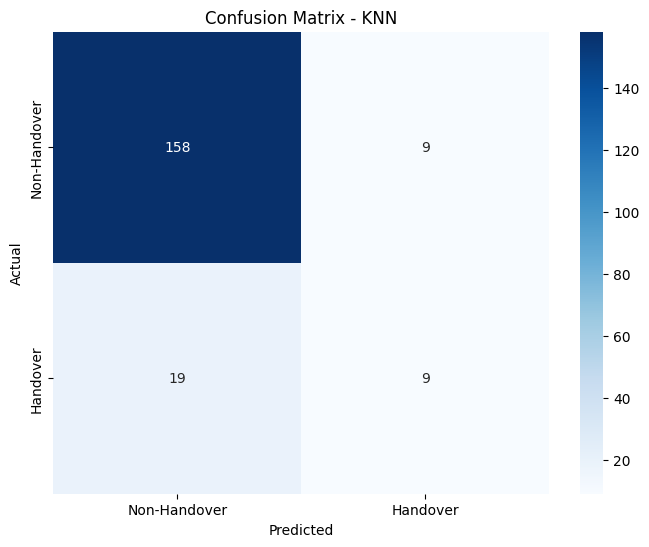

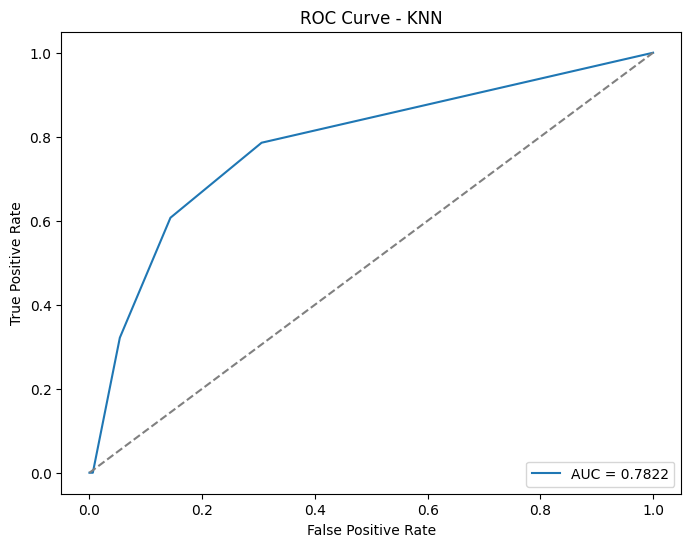

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN model
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_knn = (y_proba_knn >= threshold).astype(int)

# Evaluate model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print("Classification Report:\n", report_knn)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Precision
precision_knn = precision_score(y_test, y_pred_knn)

# Recall
recall_knn = recall_score(y_test, y_pred_knn)

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn)

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# AUC (Area Under the Curve)
auc_knn = roc_auc_score(y_test, y_proba_knn)

# ROC Curve
fpr_knn, tpr_knn, thresholds_roc_knn = roc_curve(y_test, y_proba_knn)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print(f"AUC: {auc_knn:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.7744
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.76      0.85       167
           1       0.38      0.86      0.52        28

    accuracy                           0.77       195
   macro avg       0.67      0.81      0.69       195
weighted avg       0.88      0.77      0.80       195

Threshold: 0.5
Accuracy: 0.7744
Precision: 0.3750
Recall: 0.8571
F1 Score: 0.5217
AUC: 0.8192


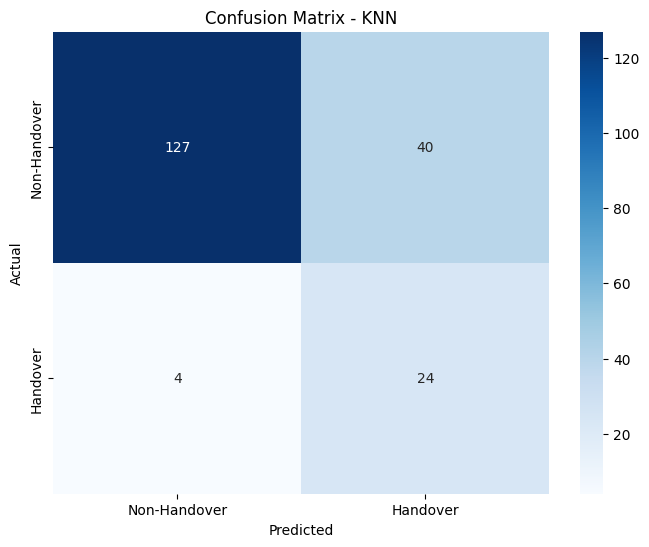

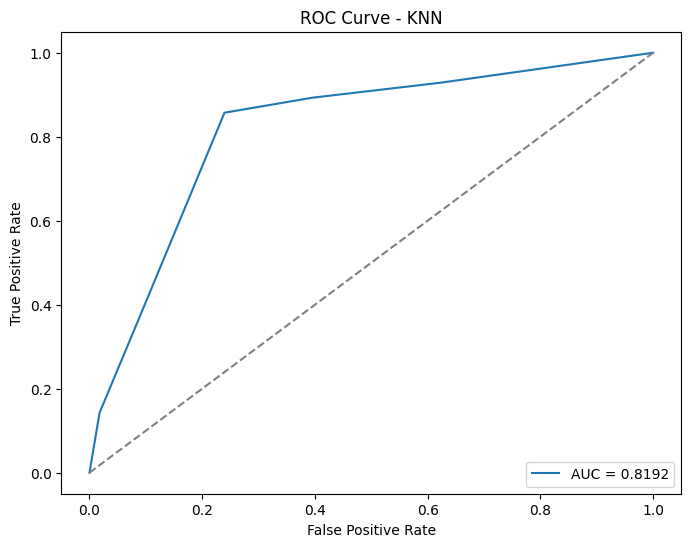

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train KNN model
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred_knn = (y_prob_knn >= threshold).astype(int)

# Evaluate model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print("Classification Report:\n", report_knn)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Precision
precision_knn = precision_score(y_test, y_pred_knn)

# Recall
recall_knn = recall_score(y_test, y_pred_knn)

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn)

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# AUC (Area Under the Curve)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# ROC Curve
fpr_knn, tpr_knn, thresholds_roc_knn = roc_curve(y_test, y_prob_knn)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print(f"AUC: {auc_knn:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Best Parameters: {'n_neighbors': 20, 'weights': 'uniform', 'metric': 'euclidean'}
Best F1 Score: 0.5714
Accuracy: 0.8308
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.84      0.89       167
           1       0.45      0.79      0.57        28

    accuracy                           0.83       195
   macro avg       0.70      0.81      0.73       195
weighted avg       0.89      0.83      0.85       195

Threshold: 0.5
Accuracy: 0.8308
Precision: 0.4490
Recall: 0.7857
F1 Score: 0.5714
AUC: 0.8606


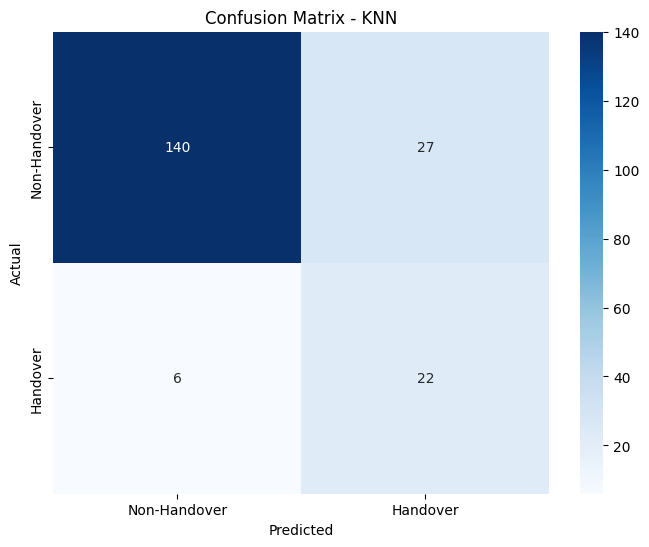

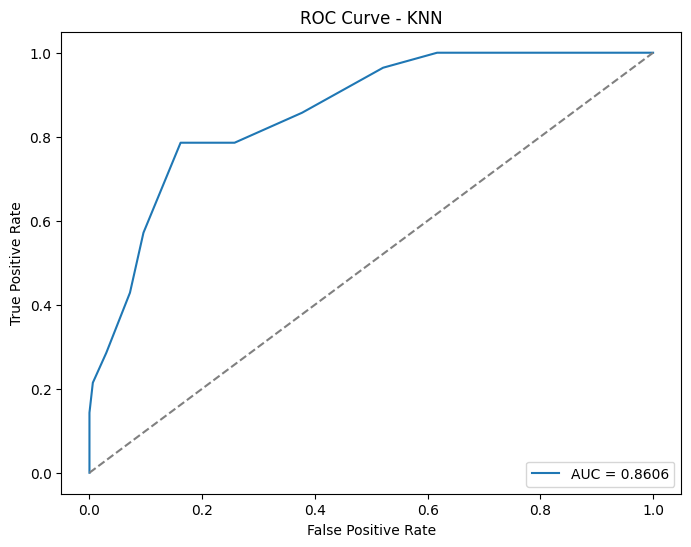

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for loops
best_f1_score = 0
best_params = {}

# Define the range of values for hyperparameters to tune
n_neighbors_range = np.arange(1, 21)  # n_neighbors from 1 to 20
weights_options = ['uniform', 'distance']
metrics_options = ['euclidean', 'manhattan', 'minkowski']

# Perform hyperparameter tuning using nested for loops
for n_neighbors in n_neighbors_range:
    for weights in weights_options:
        for metric in metrics_options:
            # Initialize KNN with current parameters
            knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)
            knn.fit(X_train_scaled, y_train_final)

            # Predict probabilities for class 1 (Handover = 1)
            y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

            # Convert probabilities to binary classification based on threshold
            threshold = 0.5
            y_pred_knn = (y_prob_knn >= threshold).astype(int)

            # Evaluate the model using F1 Score
            f1_knn = f1_score(y_test, y_pred_knn)

            # If this is the best F1 score so far, update best parameters
            if f1_knn > best_f1_score:
                best_f1_score = f1_knn
                best_params = {'n_neighbors': n_neighbors, 'weights': weights, 'metric': metric}

# Print the best parameters found by the for loop
print(f"Best Parameters: {best_params}")
print(f"Best F1 Score: {best_f1_score:.4f}")

# Train the model with the best parameters
best_knn = KNeighborsClassifier(**best_params)
best_knn.fit(X_train_scaled, y_train_final)

# Predict probabilities for class 1 (Handover = 1)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
threshold = 0.5
y_pred_knn = (y_prob_knn >= threshold).astype(int)

# Evaluate model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print("Classification Report:\n", report_knn)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Precision
precision_knn = precision_score(y_test, y_pred_knn)

# Recall
recall_knn = recall_score(y_test, y_pred_knn)

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn)

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# AUC (Area Under the Curve)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# ROC Curve
fpr_knn, tpr_knn, thresholds_roc_knn = roc_curve(y_test, y_prob_knn)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print(f"AUC: {auc_knn:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve - KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8718
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93       167
           1       0.60      0.32      0.42        28

    accuracy                           0.87       195
   macro avg       0.75      0.64      0.67       195
weighted avg       0.85      0.87      0.85       195

Threshold: 0.5
Accuracy: 0.8718
Precision: 0.6000
Recall: 0.3214
F1 Score: 0.4186
AUC: 0.8548


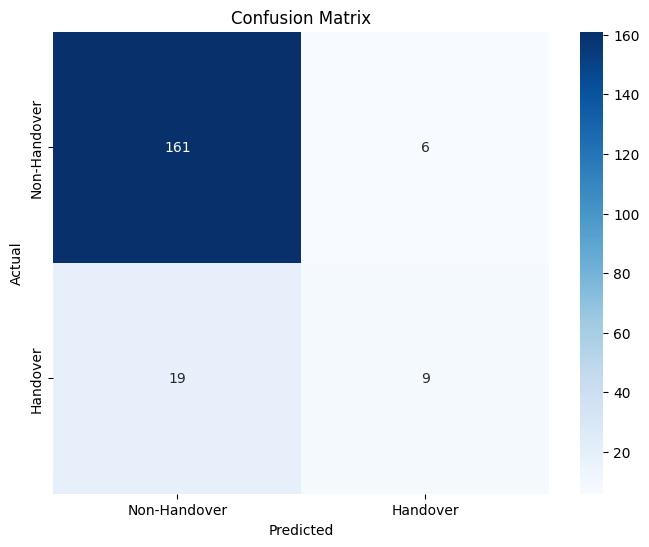

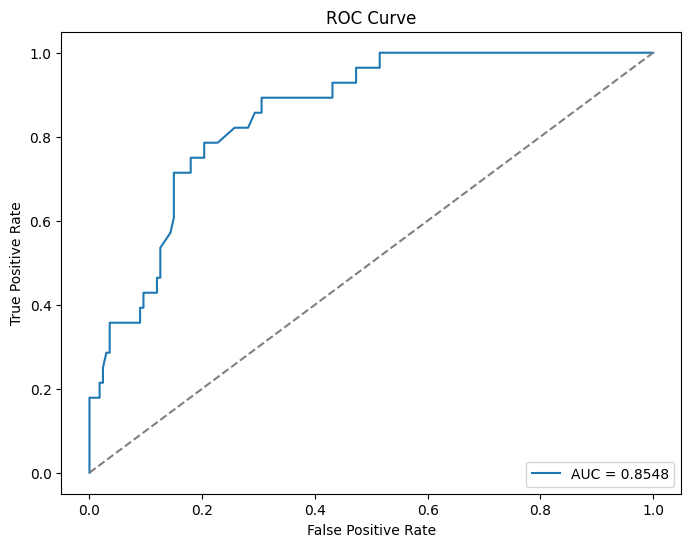

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train AdaBoost classifier model
model = AdaBoostClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8410
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90       167
           1       0.46      0.64      0.54        28

    accuracy                           0.84       195
   macro avg       0.70      0.76      0.72       195
weighted avg       0.87      0.84      0.85       195

Threshold: 0.5
Accuracy: 0.8410
Precision: 0.4615
Recall: 0.6429
F1 Score: 0.5373
AUC: 0.8806


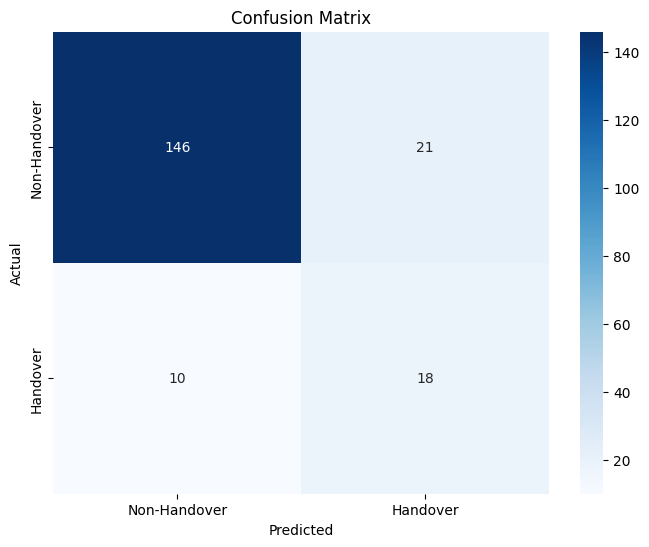

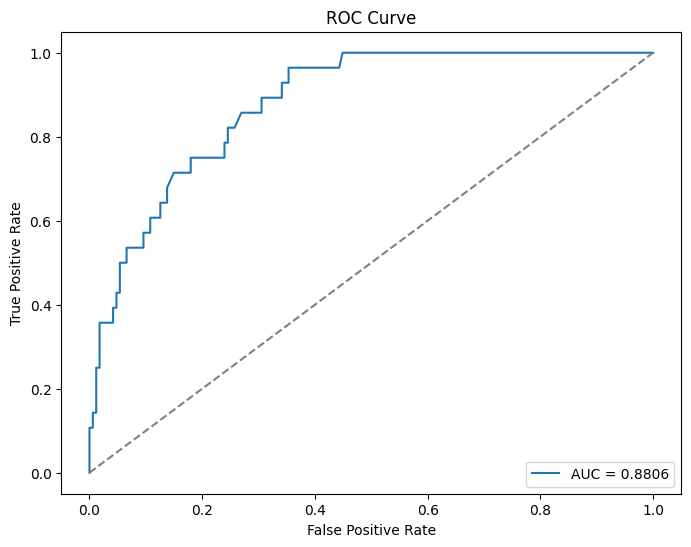

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train AdaBoost classifier model
model = AdaBoostClassifier(random_state=42)
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Best F1-score: 0.5429
Best Parameters: {'learning_rate': 0.6100000000000001, 'n_estimators': 200}
Accuracy: 0.8359
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90       167
           1       0.45      0.68      0.54        28

    accuracy                           0.84       195
   macro avg       0.70      0.77      0.72       195
weighted avg       0.87      0.84      0.85       195



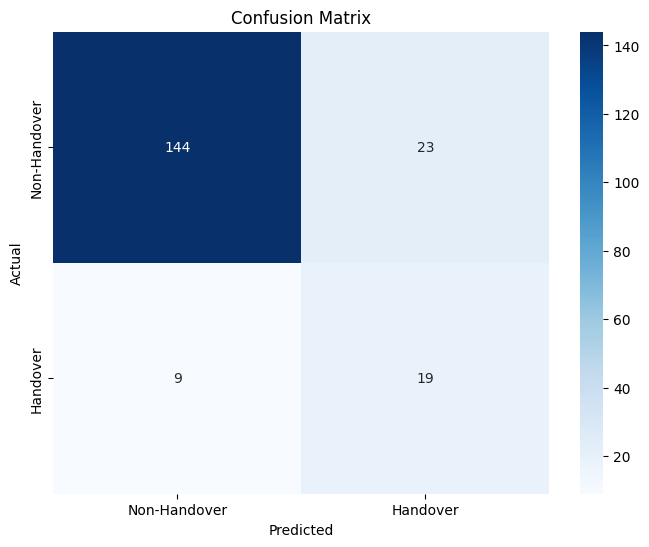

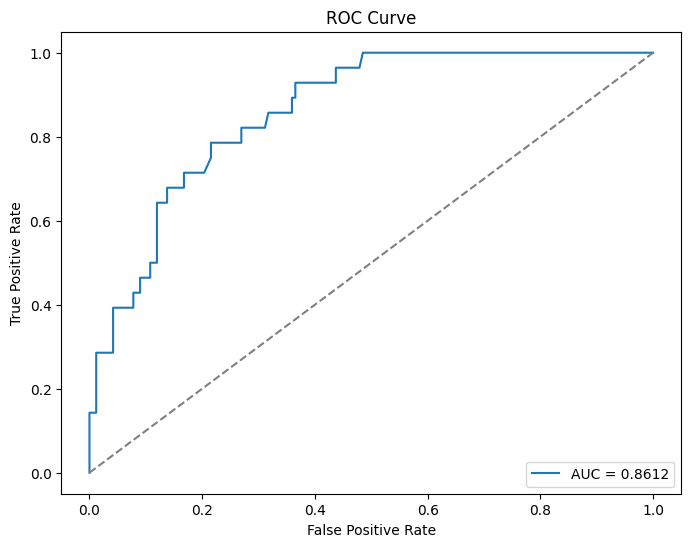

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for-loops
best_f1 = 0
best_params = {}
learning_rates = np.arange(0.01, 1.1, 0.1)  # Learning rate range
n_estimators = np.arange(50, 301, 50)  # Number of estimators range

for lr in learning_rates:
    for n in n_estimators:
        try:
            # Train AdaBoost classifier with current parameters
            model = AdaBoostClassifier(learning_rate=lr, n_estimators=n, random_state=42)
            model.fit(X_train_scaled, y_train_final)

            # Predict probabilities for class 1 (Handover = 1)
            y_prob = model.predict_proba(X_test_scaled)[:, 1]

            # Convert probabilities to binary classification based on threshold
            threshold = 0.5
            y_pred = (y_prob >= threshold).astype(int)

            # Evaluate using F1-score
            f1 = f1_score(y_test, y_pred)

            if f1 > best_f1:
                best_f1 = f1
                best_params = {'learning_rate': lr, 'n_estimators': n}

        except Exception as e:
            print(f"Skipping learning_rate={lr}, n_estimators={n} due to error: {e}")

# Train the best model
best_model = AdaBoostClassifier(learning_rate=best_params['learning_rate'], n_estimators=best_params['n_estimators'], random_state=42)
best_model.fit(X_train_scaled, y_train_final)

# Predict using the best model
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Final evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Best F1-score: {best_f1:.4f}")
print(f"Best Parameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8667
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       167
           1       0.56      0.36      0.43        28

    accuracy                           0.87       195
   macro avg       0.73      0.65      0.68       195
weighted avg       0.85      0.87      0.85       195

Threshold: 0.5
Accuracy: 0.8667
Precision: 0.5556
Recall: 0.3571
F1 Score: 0.4348
AUC: 0.8552


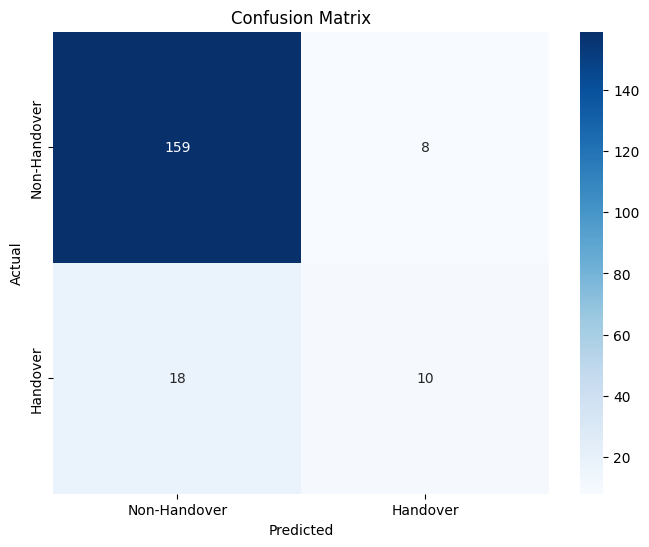

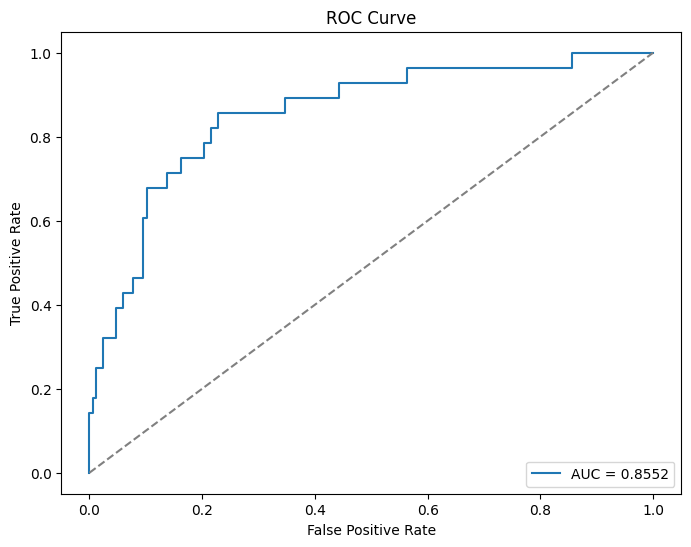

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8513
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91       167
           1       0.49      0.71      0.58        28

    accuracy                           0.85       195
   macro avg       0.72      0.79      0.74       195
weighted avg       0.88      0.85      0.86       195

Threshold: 0.5
Accuracy: 0.8513
Precision: 0.4878
Recall: 0.7143
F1 Score: 0.5797
AUC: 0.8623


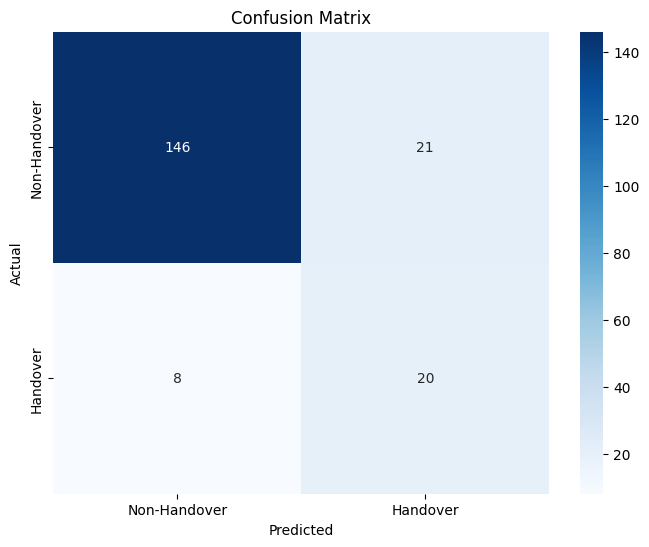

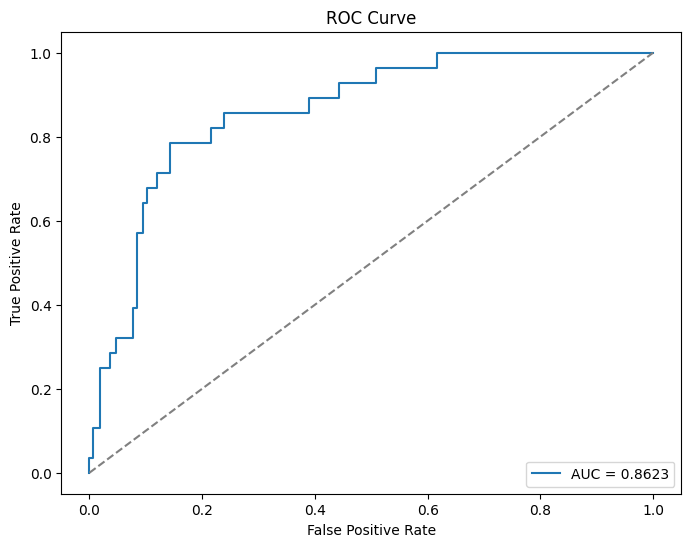

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Best F1-score: 0.5946
Best Parameters: {'n_estimators': 50, 'learning_rate': 0.26}
Accuracy: 0.8462
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.86      0.91       167
           1       0.48      0.79      0.59        28

    accuracy                           0.85       195
   macro avg       0.72      0.82      0.75       195
weighted avg       0.89      0.85      0.86       195



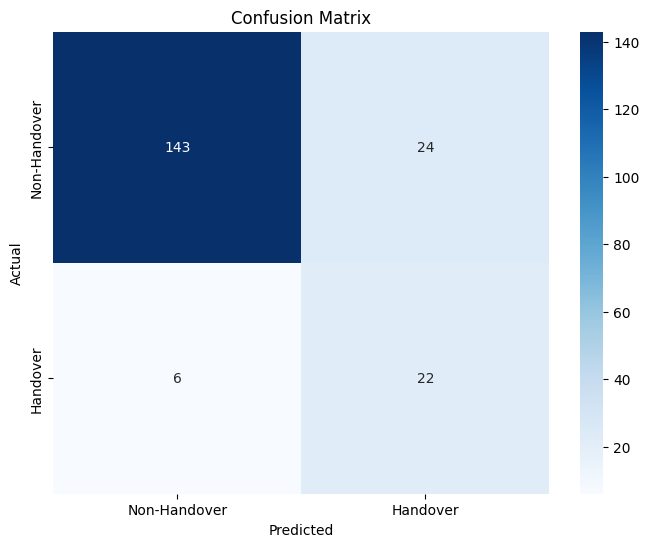

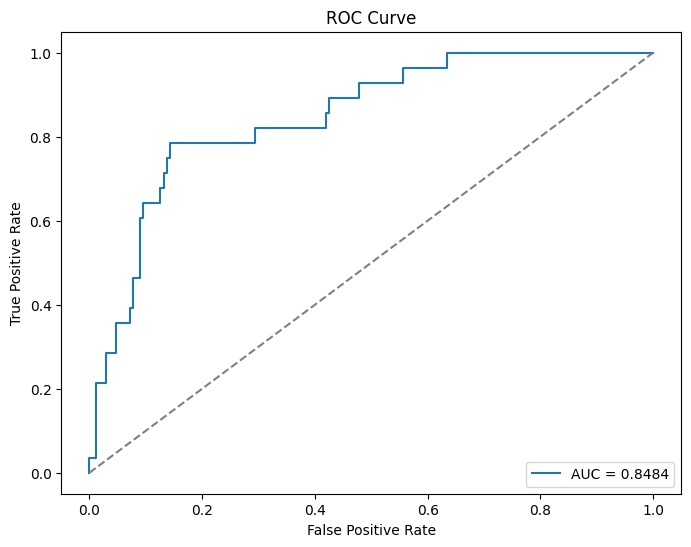

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using for-loops with arange
best_f1 = 0
best_params = {}

n_estimators_values = np.arange(50, 200, 50)  # From 50 to 150 with a step of 50
learning_rates = np.arange(0.01, 0.3, 0.05)   # From 0.01 to 0.25 with a step of 0.05

for n_estimators in n_estimators_values:
    for learning_rate in learning_rates:
        model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
        model.fit(X_train_scaled, y_train_final)

        # Predict probabilities
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

        # Convert probabilities to binary classification based on threshold
        threshold = 0.5
        y_pred = (y_prob >= threshold).astype(int)

        # Evaluate using F1-score
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate}

# Train the best model
best_model = GradientBoostingClassifier(n_estimators=best_params['n_estimators'], learning_rate=best_params['learning_rate'], random_state=42)
best_model.fit(X_train_scaled, y_train_final)

# Predict using best model
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Final evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

print(f"Best F1-score: {best_f1:.4f}")
print(f"Best Parameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [ ]:
pip install xgboost

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 4.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:56:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8615
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       167
           1       0.52      0.39      0.45        28

    accuracy                           0.86       195
   macro avg       0.71      0.67      0.68       195
weighted avg       0.85      0.86      0.85       195

Threshold: 0.5
Accuracy: 0.8615
Precision: 0.5238
Recall: 0.3929
F1 Score: 0.4490
AUC: 0.8777


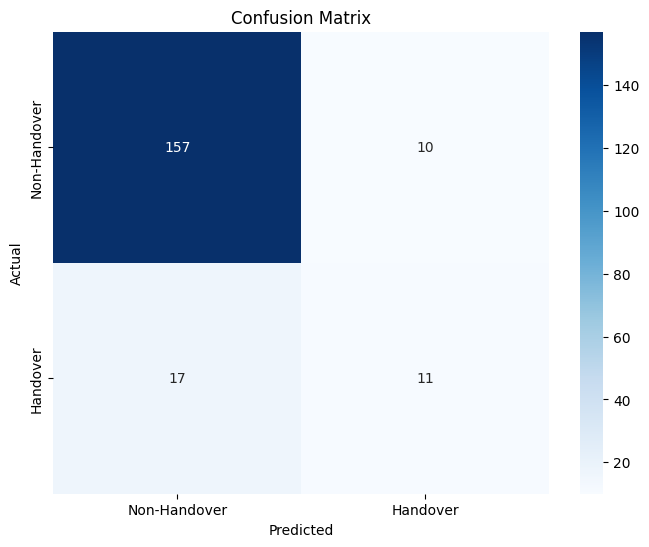

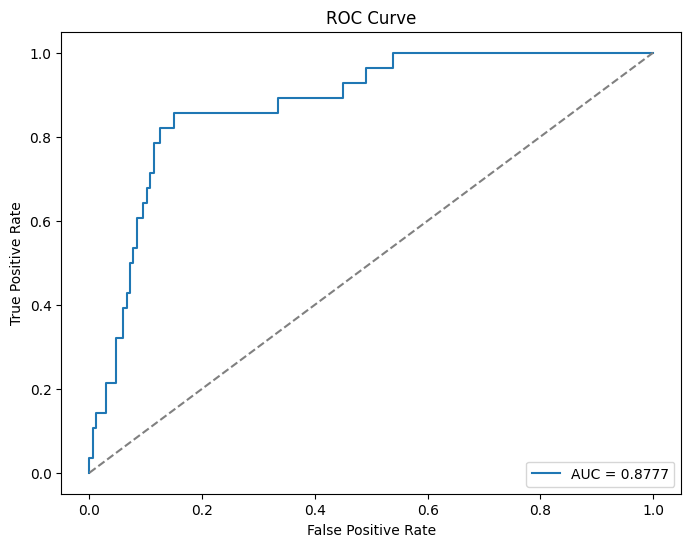

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:59:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8359
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       167
           1       0.46      0.82      0.59        28

    accuracy                           0.84       195
   macro avg       0.71      0.83      0.74       195
weighted avg       0.89      0.84      0.85       195

Threshold: 0.5
Accuracy: 0.8359
Precision: 0.4600
Recall: 0.8214
F1 Score: 0.5897
AUC: 0.8904


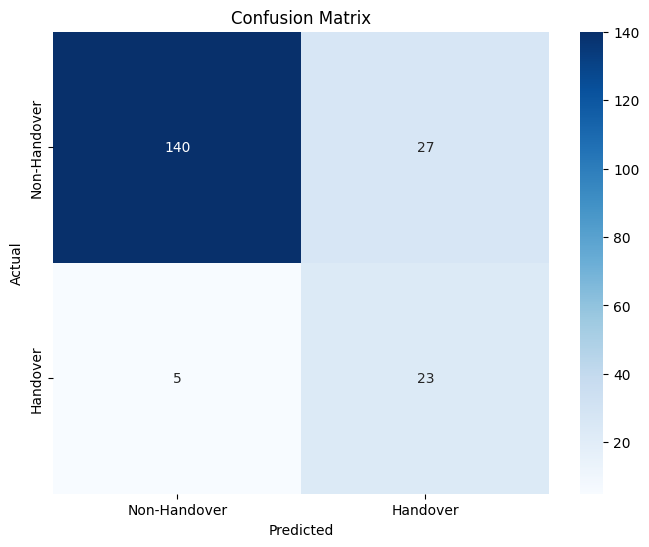

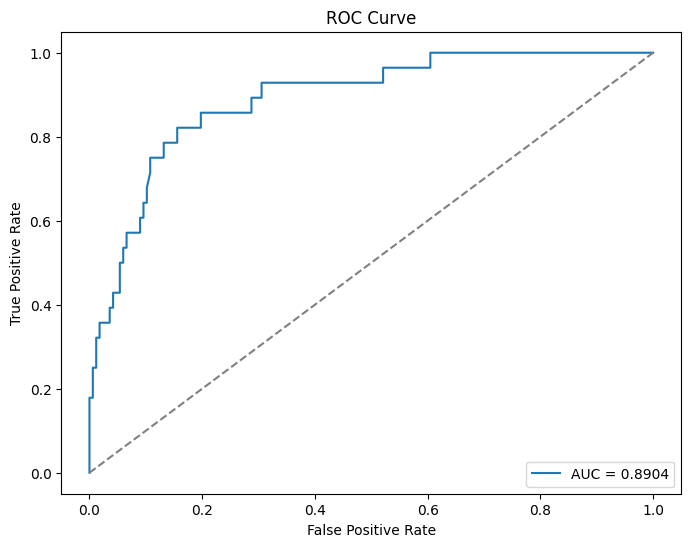

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best Parameters: {'n_estimators': 50, 'learning_rate': 0.2, 'max_depth': 3}
Accuracy: 0.8462
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90       167
           1       0.48      0.82      0.61        28

    accuracy                           0.85       195
   macro avg       0.72      0.84      0.75       195
weighted avg       0.90      0.85      0.86       195

AUC: 0.8829


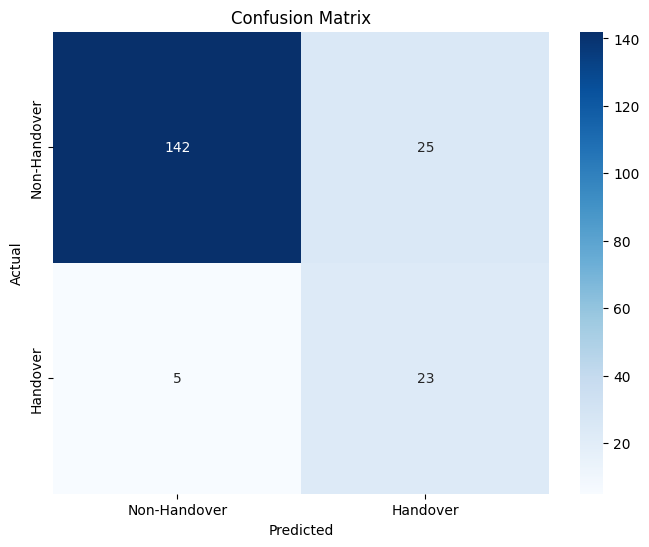

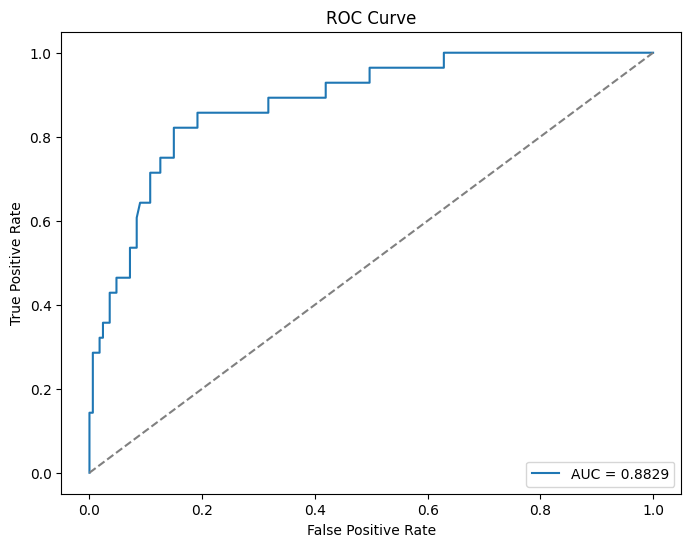

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning
best_f1 = 0
best_params = {}

for n_estimators in np.arange(50, 201, 50):
    for learning_rate in np.arange(0.05, 0.31, 0.05):
        for max_depth in np.arange(3, 8, 1):
            model = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42, use_label_encoder=False, eval_metric='logloss')
            model.fit(X_train_scaled, y_train_final)
            y_pred = model.predict(X_test_scaled)
            f1 = f1_score(y_test, y_pred)

            if f1 > best_f1:
                best_f1 = f1
                best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate, 'max_depth': max_depth}

# Train best model with optimal hyperparameters
best_model = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
best_model.fit(X_train_scaled, y_train_final)

# Predictions
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Print results
print(f"Best Parameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8923
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       167
           1       0.82      0.32      0.46        28

    accuracy                           0.89       195
   macro avg       0.86      0.65      0.70       195
weighted avg       0.89      0.89      0.87       195

Threshold: 0.5
Accuracy: 0.8923
Precision: 0.8182
Recall: 0.3214
F1 Score: 0.4615
AUC: 0.8999


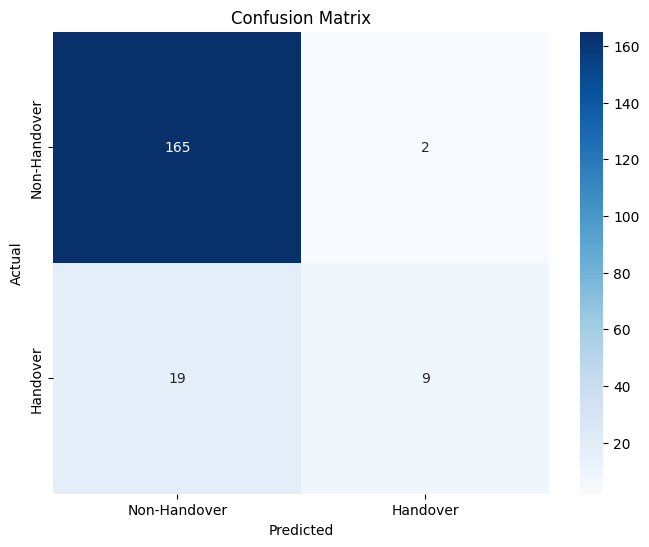

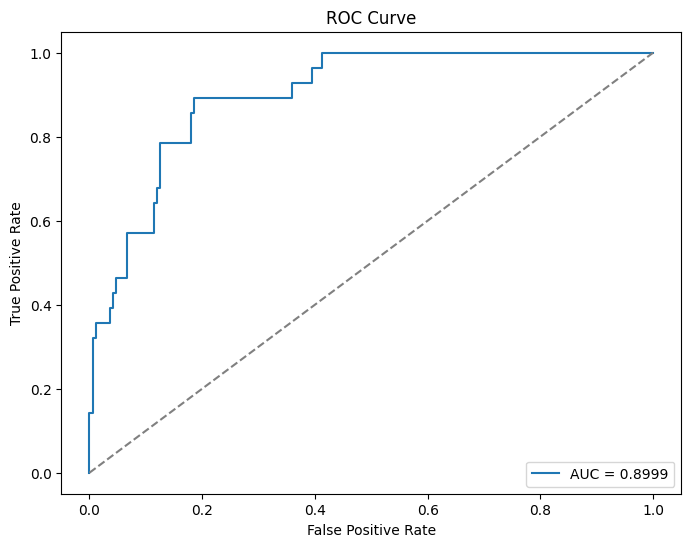

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train CatBoost model
model = CatBoostClassifier(iterations=100, learning_rate=0.1, random_seed=42, verbose=0)
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8256
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89       167
           1       0.44      0.75      0.55        28

    accuracy                           0.83       195
   macro avg       0.69      0.79      0.72       195
weighted avg       0.88      0.83      0.84       195

Threshold: 0.5
Accuracy: 0.8256
Precision: 0.4375
Recall: 0.7500
F1 Score: 0.5526
AUC: 0.8770


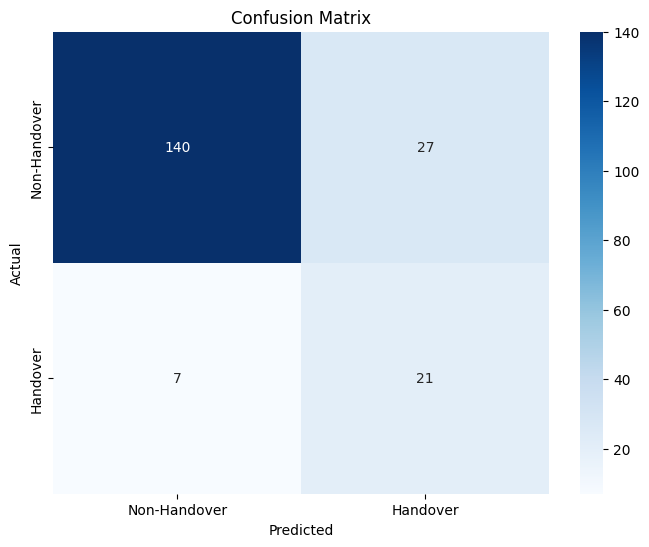

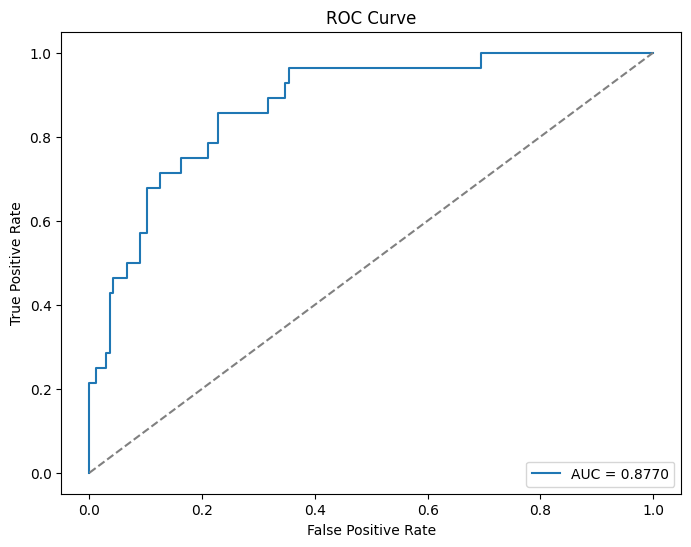

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train CatBoost model
model = CatBoostClassifier(n_estimators=100, learning_rate=0.1, depth=3, random_state=42, silent=True)
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Training with learning_rate=0.01, depth=3, n_estimators=50
Training with learning_rate=0.01, depth=3, n_estimators=100
Training with learning_rate=0.01, depth=3, n_estimators=150
Training with learning_rate=0.01, depth=5, n_estimators=50
Training with learning_rate=0.01, depth=5, n_estimators=100
Training with learning_rate=0.01, depth=5, n_estimators=150
Training with learning_rate=0.01, depth=7, n_estimators=50
Training with learning_rate=0.01, depth=7, n_estimators=100
Training with learning_rate=0.01, depth=7, n_estimators=150
Training with learning_rate=0.01, depth=9, n_estimators=50
Training with learning_rate=0.01, depth=9, n_estimators=100
Training with learning_rate=0.01, depth=9, n_estimators=150
Training with learning_rate=0.060000000000000005, depth=3, n_estimators=50
Training with learning_rate=0.060000000000000005, depth=3, n_estimators=100
Training with learning_rate=0.060000000000000005, depth=3, n_estimators=150
Training with learning_rate=0.060000000000000005, depth=5

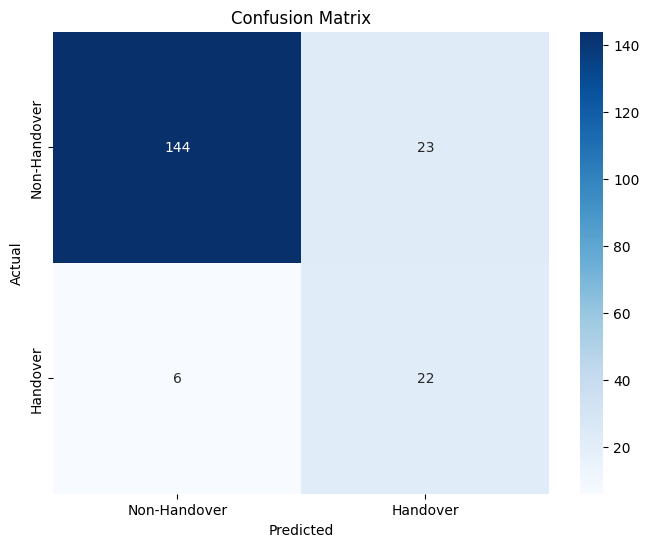

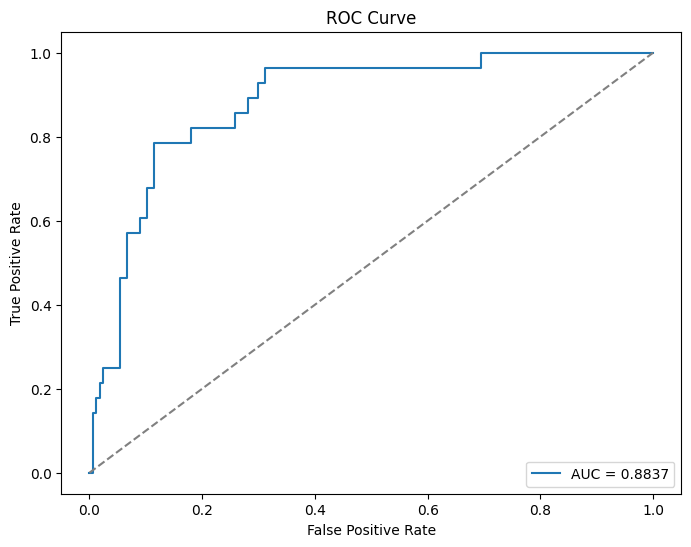

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using a for loop
best_f1 = 0  # To track the best F1 score
best_params = {}  # To track the best hyperparameters

# Define parameter ranges to test
learning_rates = np.arange(0.01, 0.2, 0.05)
depths = np.arange(3, 10, 2)
estimators = [50, 100, 150]

# Loop through all combinations of hyperparameters
for lr in learning_rates:
    for depth in depths:
        for n_estimators in estimators:
            print(f"Training with learning_rate={lr}, depth={depth}, n_estimators={n_estimators}")

            # Train CatBoost model with the current hyperparameters
            model = CatBoostClassifier(n_estimators=n_estimators, learning_rate=lr, depth=depth, random_state=42, silent=True)
            model.fit(X_train_scaled, y_train_final)

            # Predict probabilities for class 1 (Handover = 1)
            y_prob = model.predict_proba(X_test_scaled)[:, 1]

            # Convert probabilities to binary classification based on threshold
            threshold = 0.5
            y_pred = (y_prob >= threshold).astype(int)

            # Calculate F1 score
            f1 = f1_score(y_test, y_pred)

            # If this is the best F1 score, save the model and hyperparameters
            if f1 > best_f1:
                best_f1 = f1
                best_params = {'learning_rate': lr, 'depth': depth, 'n_estimators': n_estimators}

# Train the best model using the best hyperparameters
best_model = CatBoostClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    random_state=42,
    silent=True
)
best_model.fit(X_train_scaled, y_train_final)

# Predict using the best model
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_best >= threshold).astype(int)

# Evaluate the best model
accuracy = accuracy_score(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best)

print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred_best)

# Recall
recall = recall_score(y_test, y_pred_best)

# F1 Score
f1 = f1_score(y_test, y_pred_best)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob_best)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_best)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8615
Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93       167
           1       1.00      0.04      0.07        28

    accuracy                           0.86       195
   macro avg       0.93      0.52      0.50       195
weighted avg       0.88      0.86      0.80       195

Threshold: 0.5
Accuracy: 0.8615
Precision: 1.0000
Recall: 0.0357
F1 Score: 0.0690
AUC: 0.9087


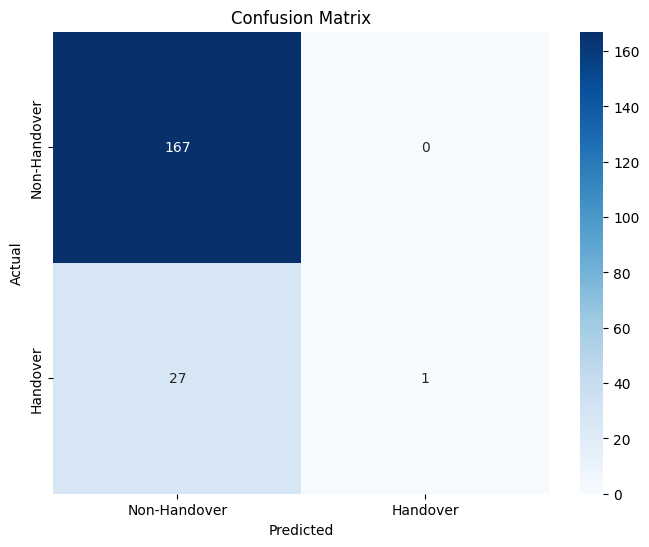

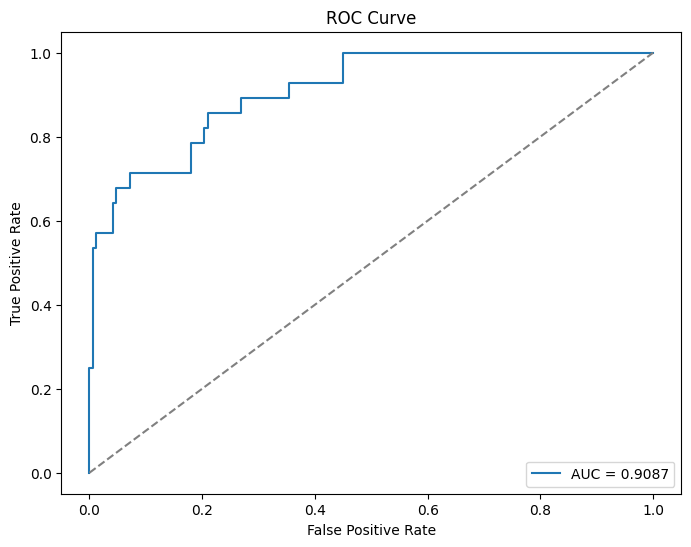

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.naive_bayes import GaussianNB  # Import Naive Bayes
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Naive Bayes model (GaussianNB)
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8462
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.91       167
           1       0.47      0.68      0.56        28

    accuracy                           0.85       195
   macro avg       0.71      0.78      0.73       195
weighted avg       0.87      0.85      0.86       195

Threshold: 0.5
Accuracy: 0.8462
Precision: 0.4750
Recall: 0.6786
F1 Score: 0.5588
AUC: 0.8398


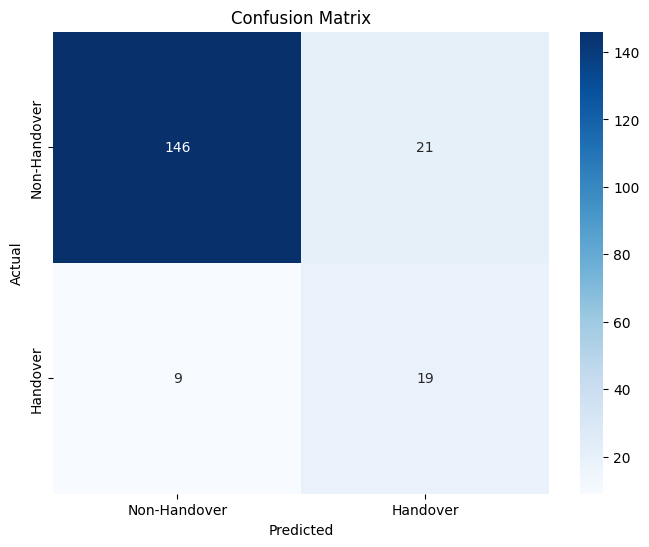

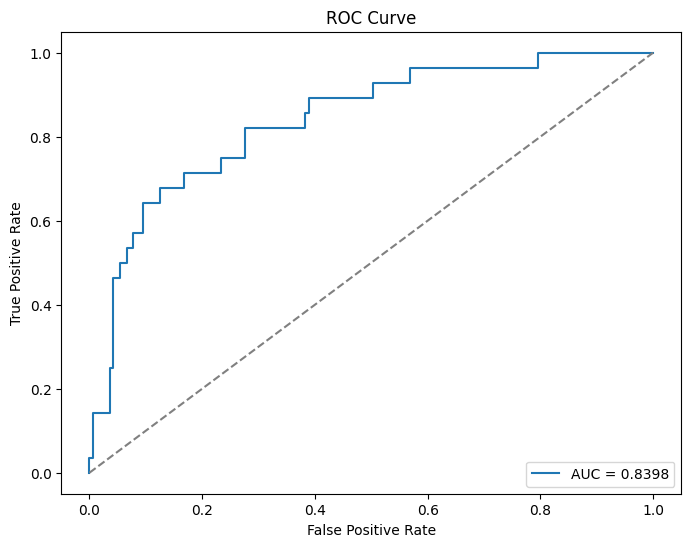

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.naive_bayes import GaussianNB  # Import Naive Bayes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train Naive Bayes model (GaussianNB)
model = GaussianNB()
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Training with var_smoothing=1e-10
Training with var_smoothing=1.2915496650148826e-09
Training with var_smoothing=1.6681005372000592e-08
Training with var_smoothing=2.1544346900318867e-07
Training with var_smoothing=2.782559402207126e-06
Training with var_smoothing=3.5938136638046256e-05
Training with var_smoothing=0.0004641588833612782
Training with var_smoothing=0.005994842503189421
Training with var_smoothing=0.07742636826811278
Training with var_smoothing=1.0
Best Hyperparameters: {'var_smoothing': 1.0}
Accuracy: 0.8769
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93       167
           1       0.57      0.61      0.59        28

    accuracy                           0.88       195
   macro avg       0.75      0.76      0.76       195
weighted avg       0.88      0.88      0.88       195

Threshold: 0.5
Accuracy: 0.8769
Precision: 0.5667
Recall: 0.6071
F1 Score: 0.5862
AUC: 0.8764


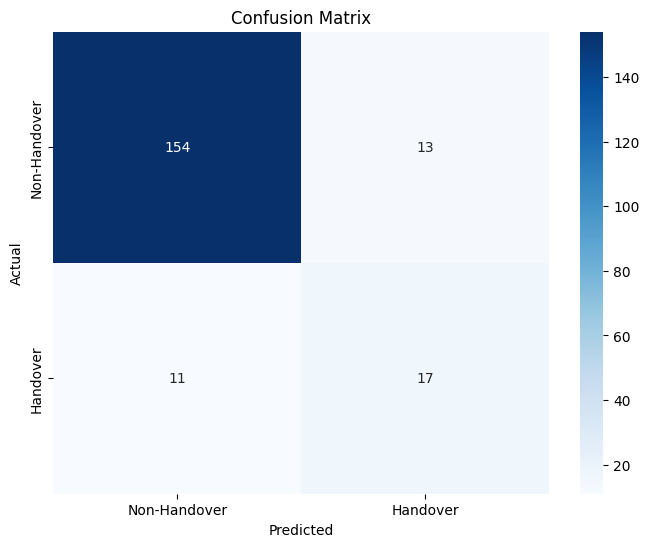

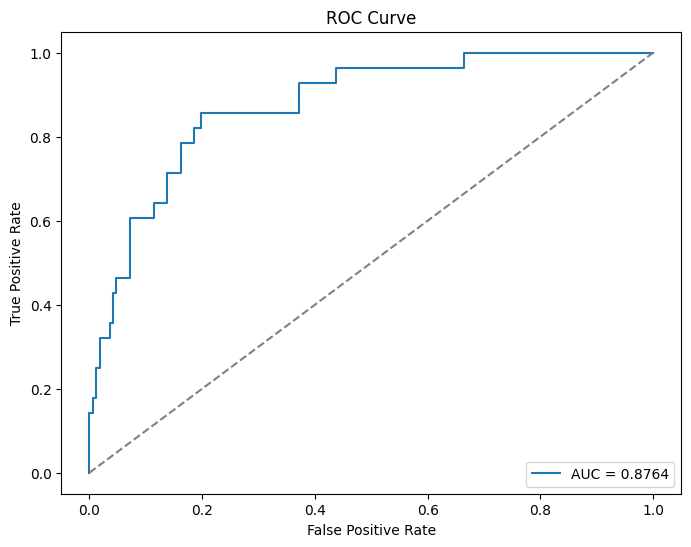

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using a for loop
best_f1 = 0  # To track the best F1 score
best_params = {}  # To track the best hyperparameters

# Define parameter ranges to test
var_smoothing_values = np.logspace(-10, 0, 10)  # Values for 'var_smoothing' parameter in Naive Bayes

# Loop through all combinations of hyperparameters
for var_smoothing in var_smoothing_values:
    print(f"Training with var_smoothing={var_smoothing}")

    # Train Naive Bayes model with the current hyperparameter
    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(X_train_scaled, y_train_final)

    # Predict using the model
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Convert probabilities to binary classification based on threshold
    threshold = 0.5
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)

    # If this is the best F1 score, save the model and hyperparameters
    if f1 > best_f1:
        best_f1 = f1
        best_params = {'var_smoothing': var_smoothing}

# Train the best model using the best hyperparameters
best_model = GaussianNB(var_smoothing=best_params['var_smoothing'])
best_model.fit(X_train_scaled, y_train_final)

# Predict using the best model
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_best >= threshold).astype(int)

# Evaluate the best model
accuracy = accuracy_score(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best)

print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Precision
precision = precision_score(y_test, y_pred_best)

# Recall
recall = recall_score(y_test, y_pred_best)

# F1 Score
f1 = f1_score(y_test, y_pred_best)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob_best)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_best)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8974
Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       167
           1       1.00      0.29      0.44        28

    accuracy                           0.90       195
   macro avg       0.95      0.64      0.69       195
weighted avg       0.91      0.90      0.87       195

Threshold: 0.5
Accuracy: 0.8974
Precision: 1.0000
Recall: 0.2857
F1 Score: 0.4444
AUC: 0.9363


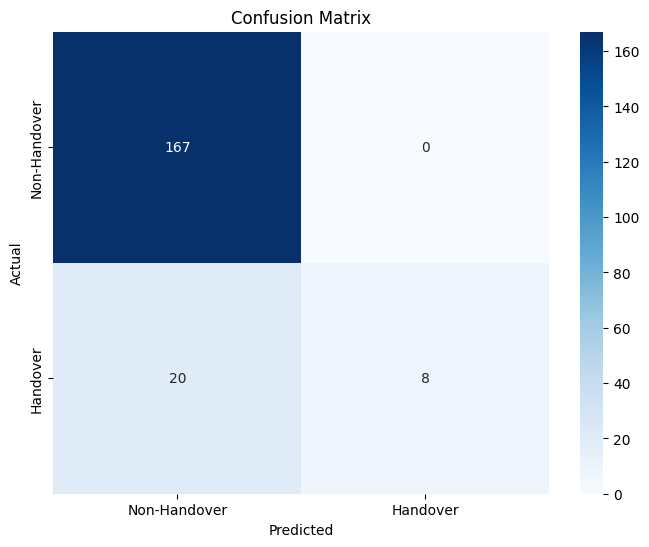

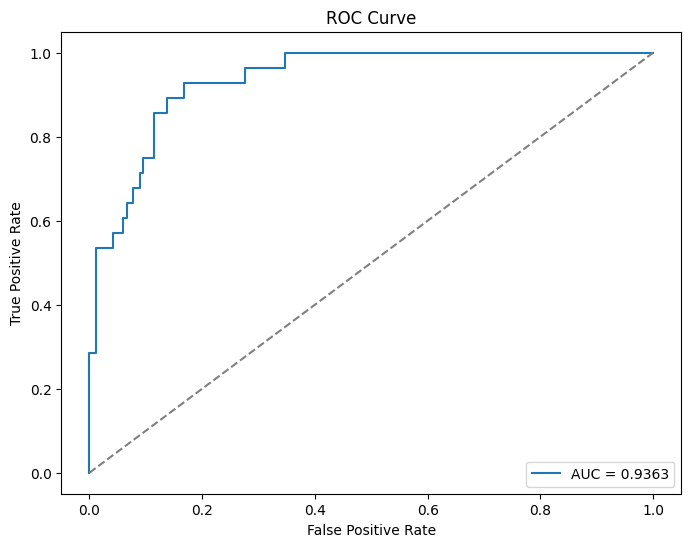

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM model with a linear kernel
model = SVC(probability=True, kernel='linear', random_state=42)
model.fit(X_train_scaled, y_train)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_proba >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.8308
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.90       167
           1       0.45      0.75      0.56        28

    accuracy                           0.83       195
   macro avg       0.70      0.80      0.73       195
weighted avg       0.88      0.83      0.85       195

Threshold: 0.5
Accuracy: 0.8308
Precision: 0.4468
Recall: 0.7500
F1 Score: 0.5600
AUC: 0.8736


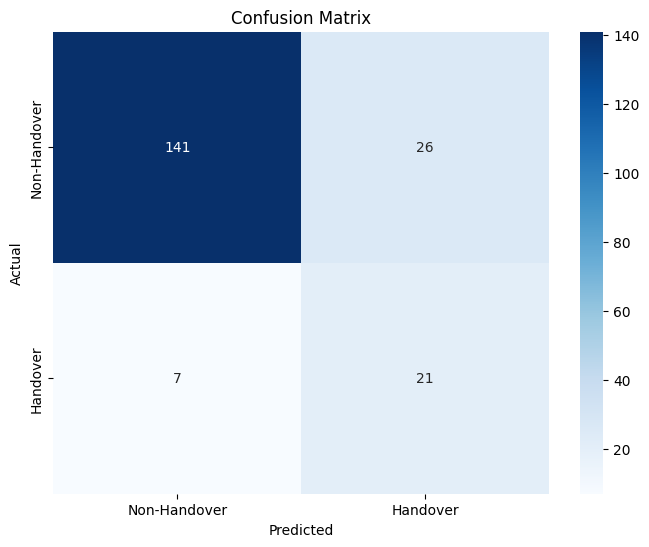

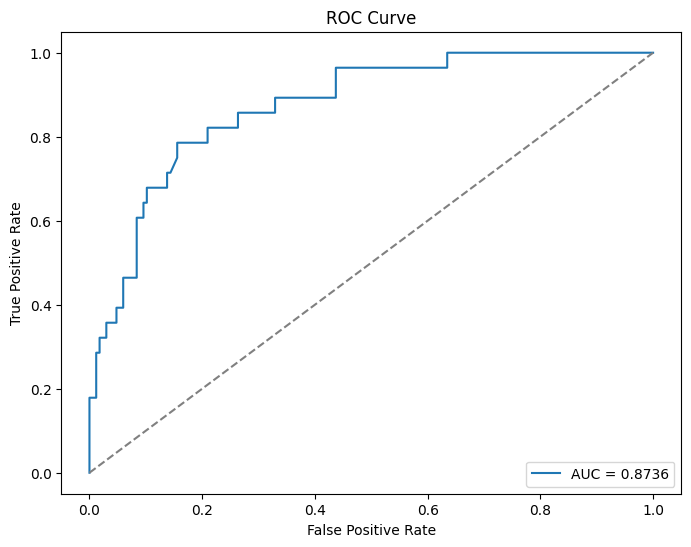

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Train SVM model (with probability=True for ROC curve calculations)
model = SVC(kernel="rbf", probability=True, random_state=42)
model.fit(X_train_scaled, y_train_final)

# Manually define threshold
threshold = 0.5

# Predict probabilities for class 1 (Handover = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to binary classification based on threshold
y_pred = (y_prob >= threshold).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Best Parameters: {'C': 1.1000000000000003, 'gamma': 0.01}
Best F1 Score: 0.6441
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90       167
           1       0.45      0.71      0.56        28

    accuracy                           0.84       195
   macro avg       0.70      0.79      0.73       195
weighted avg       0.88      0.84      0.85       195



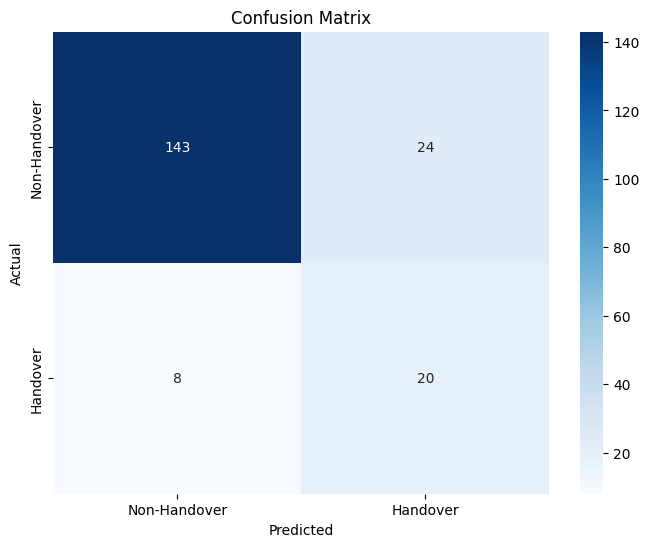

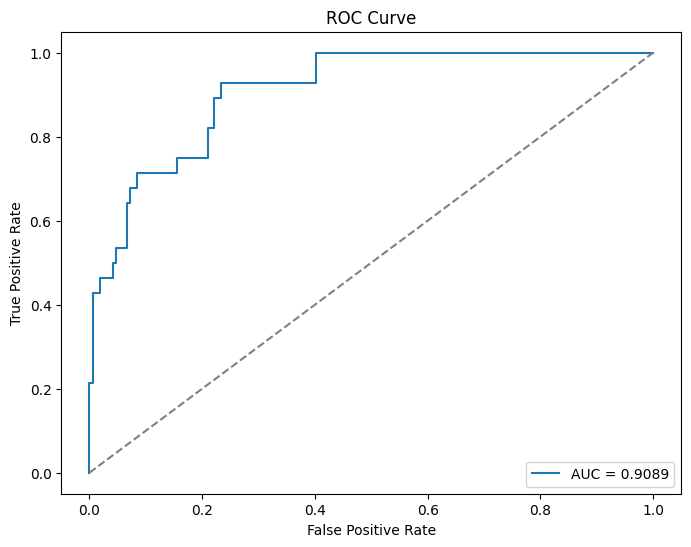

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with actual dataset path)
df = pd.read_csv("/content/Day2Data.csv")
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]
y = df['Handover']

# Step 1: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Apply Random Undersampling (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 3: Apply SMOTE to balance classes after undersampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rus, y_train_rus)

# Step 4: Apply Tomek Links to remove borderline samples
tomek = TomekLinks()
X_train_final, y_train_final = tomek.fit_resample(X_train_smote, y_train_smote)

# Step 5: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning for best F1-score
best_f1 = 0
best_params = {}

C_range = np.arange(0.1, 2.1, 0.2)  # Regularization parameter
gamma_range = np.arange(0.01, 1.1, 0.1)  # Kernel coefficient

for C in C_range:
    for gamma in gamma_range:
        model = SVC(kernel="rbf", C=C, gamma=gamma, probability=True, random_state=42)
        model.fit(X_train_scaled, y_train_final)
        y_pred = model.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_params = {'C': C, 'gamma': gamma}

# Train the best model
best_model = SVC(kernel="rbf", C=best_params['C'], gamma=best_params['gamma'], probability=True, random_state=42)
best_model.fit(X_train_scaled, y_train_final)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

print(f"Best Parameters: {best_params}")
print(f"Best F1 Score: {best_f1:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
